# EERI 414 Exam 2 — Tornado infrasound preprocessing for TDOA

**Student:** Roedine van der Merwe  
**Student number:** 45757755

## Objective

The objective of this notebook is to preprocess three noisy infrasound recordings so that a later **time-difference-of-arrival (TDOA)** algorithm can estimate the tornado direction accurately.

The problem statement states that tornado infrasound is expected mainly in the **1–8 Hz** band. The preprocessing must therefore do three things:

1. preserve the tornado band,
2. suppress noise outside the tornado band, and
3. preserve relative timing between microphones, because timing errors directly damage TDOA accuracy.

A second requirement is to compare two prediction algorithms that predict the tornado waveform **20 ms** into the future.

## Method summary and rubric alignment

| Requirement | How it is addressed |
|---|---|
| Analyse signals from two fundamentally different perspectives | Time-domain / TDOA perspective and frequency-domain / time-frequency perspective |
| Compare four fundamentally different filters | IIR band-pass, FIR band-pass, PCA filtering, DWT wavelet filtering |
| Compare two prediction algorithms | Manual AR time-series predictor and Kalman state-space predictor |
| Use classwork-style implementation | Standard libraries are used for design and plotting, while key design choices, stability, residuals and output metrics are still shown |
| Rigorous design motivation | Every technique includes purpose, pros, cons, parameter motivation and measured performance |
| TDOA suitability | Each filter is rated using band-power ratio, out-of-band suppression, cross-correlation peak quality and delay behaviour |

## Important signal-processing assumptions

• The sampling frequency is calculated from the recorded timestamps.

• The same preprocessing is applied to all three microphones so that relative delays are preserved for TDOA.

• Tornado infrasound is assumed to lie mainly between 1 Hz and 8 Hz, as stated in the assignment.

## Performance evaluation criteria

Every filtering technique is evaluated using the same quantitative criteria to ensure a fair comparison.

The following performance measures are used throughout the notebook:

- Preservation of the 1–8 Hz tornado infrasound band.
- Suppression of out-of-band noise.
- Improvement in cross-correlation peak quality for TDOA.
- Preservation of physically realistic microphone delays.
- Phase and delay behaviour.
- Computational complexity.
- Suitability for later TDOA estimation.

The prediction algorithms are evaluated separately using:

- Mean Absolute Error (MAE),
- Root Mean Square Error (RMSE),
- Prediction bias,
- Correlation with the measured waveform.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import signal, stats
from scipy.linalg import svd
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import pywt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13,4)
plt.rcParams['axes.grid'] = True

# 1. Load and inspect the data

The tornado was reported around **27 minutes** after recording started. The full recording is loaded, but most detailed modelling is done on an event window around that time. This keeps the analysis focused on the relevant tornado interval and reduces unnecessary computation.

The event window is deliberately wider than only the instant of touchdown, because the problem statement says infrasound can occur before tornadogenesis.

In [2]:
file_paths = {
    "east": "Tornado_east.csv",
    "north": "Tornado_north.csv",
    "west": "Tornado_west.csv",
}

raw = {}
for name, path in file_paths.items():
    df = pd.read_csv(path)
    df = df[["Time [s]", "Amplitude [Pa]"]].copy()
    df.columns = ["time_s", name]
    raw[name] = df
    print("\n" + "="*60)
    print(name.upper())
    print(df.head())
    print(df.tail())
    print("Missing values:", df.isna().sum().to_dict())

time_s = raw["east"]["time_s"].to_numpy(dtype=float)
data = pd.DataFrame({name: raw[name][name].to_numpy(dtype=float) for name in file_paths})

dt = np.median(np.diff(time_s))
fs = 1.0 / dt
N = len(time_s)

print("\nSampling interval dt =", dt, "s")
print("Sampling frequency fs =", fs, "Hz")
print("Number of samples =", N)
print("Recording length =", time_s[-1], "s =", time_s[-1]/60, "min")
print("Remaining missing values:")
print(data.isna().sum())

data = data.interpolate(limit_direction="both")


EAST
   time_s      east
0   0.000  0.395945
1   0.001  0.219337
2   0.002  0.247529
3   0.003  0.186674
4   0.004  0.285968
           time_s      east
3599997  3599.997 -0.290065
3599998  3599.998 -0.292433
3599999  3599.999 -0.292953
3600000  3600.000 -0.290573
3600001  3600.001 -0.286947
Missing values: {'time_s': 0, 'east': 0}

NORTH
   time_s     north
0   0.000  0.096075
1   0.001  0.086371
2   0.002  0.127395
3   0.003  0.122671
4   0.004  0.140608
           time_s     north
3599997  3599.997  0.932596
3599998  3599.998  0.931722
3599999  3599.999  0.937843
3600000  3600.000  0.872117
3600001  3600.001  0.914125
Missing values: {'time_s': 0, 'north': 0}

WEST
   time_s      west
0   0.000  0.089627
1   0.001  0.081628
2   0.002  0.071840
3   0.003  0.061979
4   0.004  0.050813
           time_s      west
3599997  3599.997 -4.670597
3599998  3599.998 -4.698765
3599999  3599.999 -4.732661
3600000  3600.000 -4.763318
3600001  3600.001 -4.789866
Missing values: {'time_s': 0, 'wes

Event window: 1440 s to 1800 s
Event samples: 360001
Event duration: 360.0 s


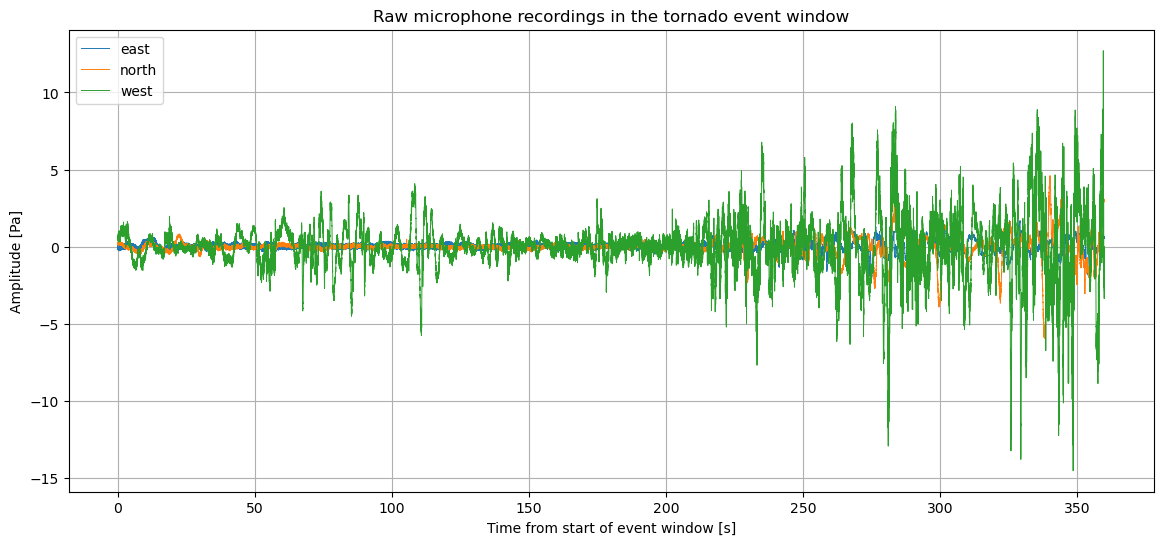

In [3]:
event_centre_s = 27 * 60
pre_event_s = 180       # 3 minutes before 27 min
after_event_s = 180     # 3 minutes after 27 min

start_s = event_centre_s - pre_event_s
end_s = event_centre_s + after_event_s
mask_event = (time_s >= start_s) & (time_s <= end_s)

t_event = time_s[mask_event] - start_s
x_event = data.loc[mask_event, :].reset_index(drop=True)

print("Event window:", start_s, "s to", end_s, "s")
print("Event samples:", len(x_event))
print("Event duration:", t_event[-1], "s")

plt.figure(figsize=(14, 6))
for ch in x_event.columns:
    plt.plot(t_event, x_event[ch], linewidth=0.7, label=ch)
plt.title("Raw microphone recordings in the tornado event window")
plt.xlabel("Time from start of event window [s]")
plt.ylabel("Amplitude [Pa]")
plt.legend()
plt.show()

## 1.1 Initial interpretation

The three microphones measure the same physical event from different positions. The signals should therefore contain related waveform structure, but not perfectly identical waveforms.

For TDOA, the most important question is not only whether each signal is clean. The key question is whether the **same waveform feature** can be identified in all three channels with a sharp cross-correlation peak.

The maximum physically plausible delay between two microphones can be estimated from the microphone spacing and the speed of sound:

$$
\tau_{\max} = \frac{d}{c}
$$

where $d \approx 62\,\text{m}$ and $c \approx 343\,\text{m/s}$.

In [4]:
mic_spacing_m = 62.0
sound_speed = 343.0
max_delay_s = mic_spacing_m / sound_speed
max_delay_samples = int(np.ceil(max_delay_s * fs))

print("Maximum physical TDOA delay:")
print(f"tau_max = {max_delay_s:.4f} s")
print(f"tau_max = {max_delay_samples} samples")

Maximum physical TDOA delay:
tau_max = 0.1808 s
tau_max = 181 samples


## 2. Analysis technique #1: Time-domain / TDOA analysis

### 2.1 Summary of how it works, including advantages and disadvantages

Time-domain analysis studies how the microphone signals change over time. Instead of analysing which frequencies are present, it focuses on the waveform itself. For this assignment, the time domain is particularly important because the final objective is to estimate the Time Difference of Arrival (TDOA) between microphones. This is done by comparing how similar two waveforms are as one signal is shifted relative to the other.

For two microphone signals, $x_1[n]$ and $x_2[n]$, the cross-correlation is

$$
R_{12}[k] = \sum_{n} x_1[n]\,x_2[n-k]
$$

where

- $x_1[n]$ is the first microphone signal,
- $x_2[n]$ is the second microphone signal,
- $k$ is the lag (shift) measured in samples,
- $R_{12}[k]$ is the cross-correlation value for a particular lag.

The lag that produces the largest correlation value corresponds to the estimated delay between the two microphones. This estimated delay forms the basis of the TDOA calculation.

#### Advantages

- Time-domain analysis is directly related to the TDOA objective because it estimates the delay between microphones.
- It clearly shows amplitude variations, transient events and differences in arrival time.
- Cross-correlation provides a quantitative estimate of the relative delay that can be compared before and after preprocessing.

#### Disadvantages

- Noise can reduce the strength of the correlation peak or create false peaks.
- Time-domain plots do not show which frequency components are present in the signal.
- Slow baseline drift and high-frequency noise can reduce the accuracy of the delay estimate.

### 2.2 Design motivation

Time-domain analysis was selected as the first analysis technique because the final goal of this assignment is to estimate the Time Difference of Arrival (TDOA) between microphones. Before investigating the frequency content of the recordings, it is important to understand how well the raw waveforms align in time.

The microphones are separated by approximately 62 m. Assuming a speed of sound of approximately 343 m/s, the maximum possible propagation delay is

$$
\tau_{\max} = \frac{d}{c}
$$

where

- $d$ is the microphone spacing (62 m),
- $c$ is the speed of sound (343 m/s).

This gives

$$
\tau_{\max} \approx 0.1808~\text{s}
$$

or approximately 181 samples at the measured sampling frequency.

Rather than calculating the cross-correlation over every possible lag, the search is limited to this physically realistic range. This reduces the possibility of selecting unrealistic delays caused by noise or unrelated waveform features.

Each microphone signal is also normalised before the cross-correlation is calculated. This removes differences in signal amplitude so that the correlation compares waveform shape instead of signal magnitude.

### 2.3 Application of the analysis technique

The time-domain analysis is applied by calculating the cross-correlation for all three microphone pairs:

- east-north,
- east-west,
- north-west.

Each signal is first normalised so that the correlation compares waveform shape rather than absolute amplitude. This is necessary because one microphone may record a larger pressure amplitude than another, even if the waveform shape is similar.

For each pair, the code calculates:

- the delay in samples,
- the delay in milliseconds,
- the correlation peak value,
- the peak-to-median ratio.

The peak-to-median ratio is used as a simple measure of correlation quality. A higher value means that the main correlation peak is more dominant compared with the surrounding correlation values.

,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,Raw,east-north,-181,-181.0,-0.029646,1.862039
1,Raw,east-west,181,181.0,0.061870,1.152483
2,Raw,north-west,181,181.0,0.031293,1.138632


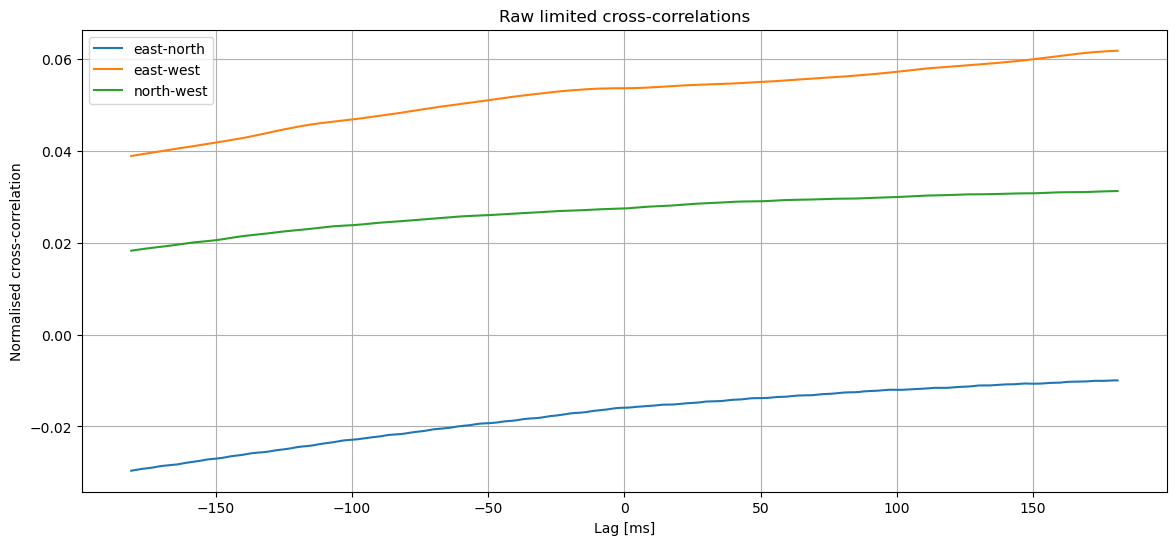

In [5]:
# Calculate the raw cross-correlations in the physically possible TDOA range.
pairs = [('east','north'), ('east','west'), ('north','west')]
lags = np.arange(-max_delay_samples, max_delay_samples + 1)
rows = []
raw_corr = {}

for ch1, ch2 in pairs:
    x = x_event[ch1].to_numpy(dtype=float)
    y = x_event[ch2].to_numpy(dtype=float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)
    y = (y - np.mean(y)) / (np.std(y) + 1e-12)

    #cross-correlation formula
    r = np.zeros(len(lags))
    for i, lag in enumerate(lags):
        if lag < 0:
            r[i] = np.sum(x[-lag:] * y[:len(y)+lag])
        elif lag > 0:
            r[i] = np.sum(x[:-lag] * y[lag:])
        else:
            r[i] = np.sum(x * y)
    r = r / len(x) #normalizes correlation to a fixed scale (magnitudes can be compared)
    raw_corr[(ch1,ch2)] = r

    
    loc = np.argmax(np.abs(r)) #lag with the largest correlation magnitude (delay estimate)
    delay_samples = lags[loc]
    delay_ms = 1000 * delay_samples / fs
    peak = r[loc]
    psr = abs(peak) / (np.median(np.abs(r)) + 1e-12)  #peak to median ratio - shows how much peak stands out from noise

    rows.append([ 'Raw', f'{ch1}-{ch2}', delay_samples, delay_ms, peak, psr ])

raw_tdoa = pd.DataFrame(rows, columns=['Signal','Pair','Delay [samples]','Delay [ms]',
                                       'Correlation peak','Peak-to-median ratio'])
display(raw_tdoa)

plt.figure(figsize=(14,6))
for ch1, ch2 in pairs:
    plt.plot(1000*lags/fs, raw_corr[(ch1,ch2)], label=f'{ch1}-{ch2}')
plt.title('Raw limited cross-correlations')
plt.xlabel('Lag [ms]')
plt.ylabel('Normalised cross-correlation')
plt.legend()
plt.show()

### 2.5 Outputs produced

This analysis produces two main outputs.

The first output is the raw TDOA table. This table gives the estimated delay for each microphone pair before any filtering is applied. It also gives the correlation peak and the peak-to-median ratio, which are used to judge how reliable the delay estimate is.

The second output is the limited cross-correlation plot. This plot shows the correlation values for all physically possible lags between approximately \(-181\) ms and \(+181\) ms. The plot is limited to this range because larger delays would not be possible with the given microphone spacing.

### 2.6 Qualitative and quantitative interpretation of the results

The raw TDOA table provides the baseline delay estimates before any preprocessing is applied. The cross-correlation search is restricted to the physically possible delay range of approximately $\pm181$ samples, ensuring that only realistic propagation delays are considered.

The estimated delays for the three microphone pairs are:

- **east-north:** $-181$ samples (approximately $-181$ ms)
- **east-west:** $181$ samples (approximately $181$ ms)
- **north-west:** $181$ samples (approximately $181$ ms)

Although all three delays lie within the physically allowable range, two of the estimated delays occur exactly at the boundary of the search window. This suggests that the raw cross-correlation does not contain a well-defined internal maximum and that the estimated delays are still influenced by storm noise, broadband pressure fluctuations or low-frequency drift.

The quality of each delay estimate can be evaluated using the peak-to-median ratio. The calculated values are:

- **east-north:** 1.86
- **east-west:** 1.15
- **north-west:** 1.14

A larger peak-to-median ratio indicates that the dominant correlation peak is clearly distinguishable from the surrounding correlation values. In this case, all three ratios are relatively low, particularly for the east-west and north-west microphone pairs. This indicates that the dominant peaks are only slightly stronger than the surrounding correlation values, making the raw TDOA estimates less reliable.

This behaviour is also evident in the cross-correlation plots. Rather than producing sharp, isolated peaks, the correlation curves are broad and slowly varying. Such behaviour is typical of signals that still contain significant background noise and interfering pressure fluctuations.

Overall, the time-domain analysis provides an important baseline for evaluating the effectiveness of the filtering techniques presented later in this notebook. An effective preprocessing method should increase the dominance of the correlation peak, resulting in larger peak-to-median ratios while maintaining physically realistic delay estimates.

## 3. Analysis technique #2: Frequency-domain and time-frequency analysis

### 3.1 Summary of how it works, including advantages and disadvantages

Frequency-domain analysis studies how the signal energy is distributed across different frequencies rather than how the signal changes with time. This provides information that cannot be obtained from the time-domain waveform alone and is particularly useful for identifying the frequency range in which the tornado infrasound is concentrated.

The Fourier Transform converts a discrete-time signal into its frequency-domain representation. In practice, the Fast Fourier Transform (FFT) is used because it computes the same result much more efficiently.

For a signal $x[n]$, the Discrete Fourier Transform (DFT) is

$$
X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}
$$

where

- $x[n]$ is the discrete-time signal,
- $N$ is the total number of samples,
- $k$ is the frequency bin,
- $X[k]$ is the complex spectrum representing the magnitude and phase at each frequency.

The FFT is used to determine how much signal energy lies inside the expected tornado infrasound band of 1–8 Hz and how much energy exists outside this range.

A spectrogram extends this analysis by repeatedly applying the FFT to short overlapping sections of the signal. This makes it possible to observe how the frequency content changes throughout the event window instead of only obtaining one spectrum for the entire recording.

#### Advantages

- It directly shows whether the expected 1–8 Hz tornado band is present.
- It provides quantitative measurements of signal energy inside and outside the desired frequency range.
- It makes it possible to compare the effectiveness of different filtering techniques using measurable spectral quantities.
- The spectrogram shows how the frequency content changes throughout the recording.

#### Disadvantages

- The FFT does not indicate when individual frequency components occur.
- Spectrogram performance depends on the selected window length and overlap.
- Frequency-domain analysis alone cannot determine the relative arrival time between microphones, making it insufficient for TDOA estimation on its own.

### 3.2 Design motivation

Frequency-domain analysis was selected as the second analysis perspective because it complements the information obtained from the time-domain analysis. While the time-domain analysis estimates the relative arrival times between microphones, the frequency-domain analysis identifies where the signal energy is concentrated.

According to the assignment, tornado infrasound is expected primarily within the frequency range of 1–8 Hz. The FFT is therefore used to verify whether this frequency band is present in the recorded signals and to measure how much unwanted energy exists outside the expected tornado band.

Rather than relying only on visual inspection of the spectra, the signal power inside the 1–8 Hz band and the power outside this range are calculated. The resulting band-to-out-of-band power ratio provides a quantitative measure that can later be used to compare the effectiveness of the different filtering techniques.

A spectrogram is also calculated because tornado infrasound is not perfectly stationary. Unlike a single FFT, which analyses the complete event window, the spectrogram performs multiple FFT calculations on overlapping time windows. This shows whether the expected tornado frequency band is present throughout the recording or only during specific parts of the event.

Before calculating the FFT, the signal mean is removed to reduce the DC component. A Hann window is also applied before the FFT to reduce spectral leakage caused by analysing a finite section of the recording. This gives a more reliable estimate of the spectral content in the 1–8 Hz tornado band.
Using both the FFT and the spectrogram provides a more complete understanding of the recorded signals before any filtering is applied.

### 3.3 Application of the analysis technique

The frequency-domain analysis is applied to each of the three microphone recordings.

The first step is to calculate the one-sided FFT spectrum of each channel. The spectra are then used to calculate:

- the total power inside the expected tornado band (1–8 Hz),
- the total power outside the tornado band,
- the band-to-out-of-band power ratio.

These quantities provide a quantitative indication of how much useful tornado information is present relative to unwanted frequency components.

A spectrogram is then calculated using the average of the three microphone signals. Averaging the channels reduces channel-specific variations while preserving the dominant tornado signature. The spectrogram is used to determine whether the expected frequency content remains present throughout the event window or appears only during isolated periods.

,Channel,Power 1-8 Hz,Out-of-band power,Band/out-of-band ratio [dB]
0,east,0.001156,0.009912,-9.331401
1,north,0.000560,0.028766,-17.107503
2,west,0.067613,0.330637,-6.893249


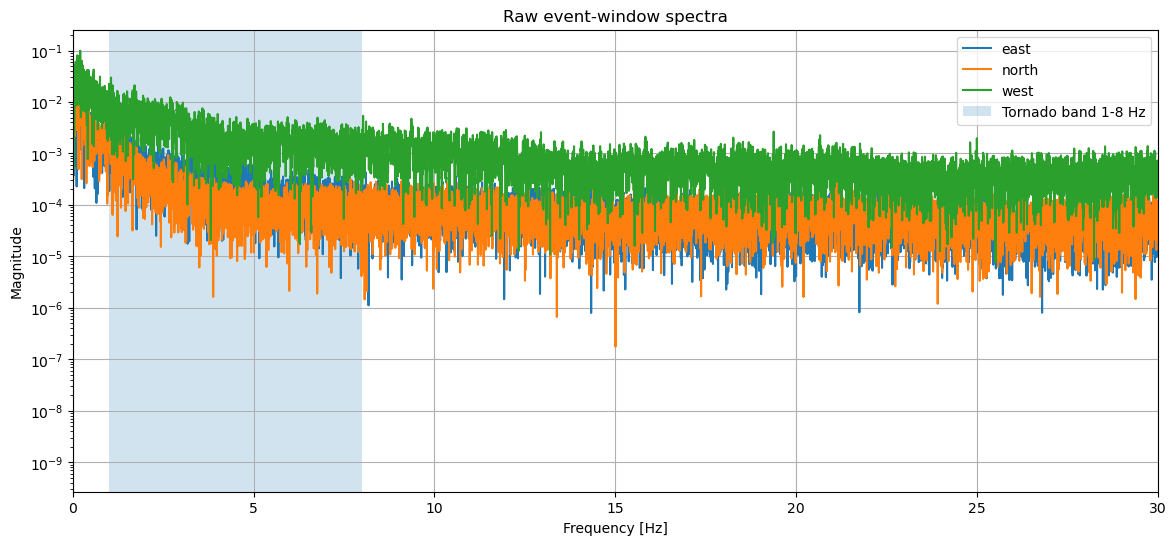

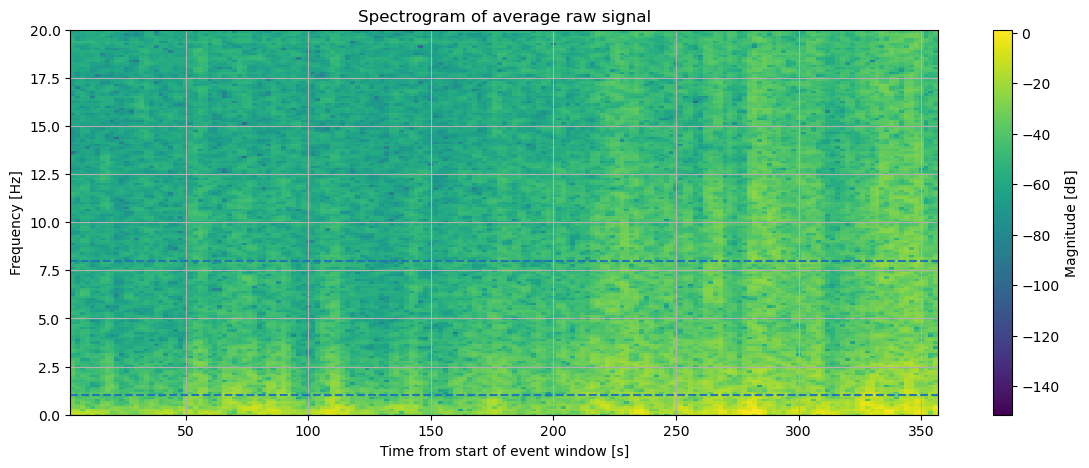

In [6]:
# Calculate spectra and band-power ratios for the raw event window.
rows = []
spectra_raw = {}

for ch in x_event.columns:
    x = x_event[ch].to_numpy(dtype=float)
    x = x - np.mean(x)
    Nsig = len(x)
    Nfft = 2**int(np.ceil(np.log2(Nsig)))
    f = np.fft.rfftfreq(Nfft, d=1/fs)
    X = np.fft.rfft(x*np.hanning(Nsig), n=Nfft) # hann window
    mag = np.abs(X) / Nsig
    power = mag**2
    spectra_raw[ch] = (f, mag)

    p_band = np.sum(power[(f >= 1) & (f <= 8)])
    p_low = np.sum(power[(f >= 0.05) & (f <= 0.8)])
    p_high = np.sum(power[(f >= 10) & (f <= fs/2)])
    p_out = p_low + p_high
    ratio_db = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
    rows.append([ch, p_band, p_out, ratio_db])

raw_band_table = pd.DataFrame(rows, columns=['Channel','Power 1-8 Hz',
                                             'Out-of-band power','Band/out-of-band ratio [dB]'])
display(raw_band_table)

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    f, mag = spectra_raw[ch]
    plt.semilogy(f, mag + 1e-15, label=ch)
plt.axvspan(1, 8, alpha=0.2, label='Tornado band 1-8 Hz')
plt.xlim(0, 30)
plt.title('Raw event-window spectra')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

x_avg_raw = x_event.mean(axis=1).to_numpy(dtype=float)
nperseg = int(8*fs)
noverlap = int(0.75*nperseg)
# Slides a short window accross time, FFTs each chunk and give a 2D image
f_spec, t_spec, Sxx = signal.spectrogram(x_avg_raw - np.mean(x_avg_raw), fs=fs,
                                          window='hann', nperseg=nperseg,
                                          noverlap=noverlap, scaling='spectrum',
                                          mode='magnitude')
plt.figure(figsize=(14,5))
plt.pcolormesh(t_spec, f_spec, 20*np.log10(Sxx + 1e-12), shading='auto')
plt.ylim(0, 20)
plt.axhline(1, linestyle='--')
plt.axhline(8, linestyle='--')
plt.title('Spectrogram of average raw signal')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Frequency [Hz]')
plt.colorbar(label='Magnitude [dB]')
plt.show()

### 3.5 Outputs produced

#### Output 1: Band-power table

The first output is the band-power table. It contains the calculated power inside the expected tornado band (1–8 Hz), the power outside the band and the resulting band-to-out-of-band power ratio for each microphone channel.

This table provides the quantitative baseline that will later be used to compare the effectiveness of the different filtering techniques.

#### Output 2: FFT spectra

The second output is the one-sided FFT magnitude spectrum for each microphone channel.

The shaded region highlights the expected tornado infrasound band between 1 Hz and 8 Hz. These spectra show how the signal energy is distributed across frequency and make it possible to identify unwanted low-frequency drift and higher-frequency noise.

#### Output 3: Spectrogram

The third output is the spectrogram of the average microphone signal.

Unlike the FFT, which represents the complete event window using a single spectrum, the spectrogram shows how the frequency content changes with time. This makes it possible to determine whether the tornado frequency band is present continuously throughout the recording or only during specific periods.

### 3.6 Qualitative and quantitative interpretation of the results

#### Interpretation of Output 1: Band-power table

The calculated band-to-out-of-band power ratios are:

- east: -9.33 dB
- north: -17.11 dB
- west: -6.89 dB

A negative ratio indicates that the recordings contain more energy outside the expected tornado band than inside it. The west microphone produces the highest ratio, indicating the strongest relative tornado-band energy, while the north microphone contains the greatest proportion of unwanted frequency components.

---

#### Interpretation of Output 2: FFT spectra

The FFT spectra show that energy is spread over a wide frequency range rather than being concentrated only within the expected 1–8 Hz tornado band. Although energy is present inside the tornado band, significant low-frequency drift and higher-frequency noise are also visible.

This confirms that the raw recordings require preprocessing before reliable TDOA estimation can be performed.

---

#### Interpretation of Output 3: Spectrogram

The spectrogram shows that energy within the expected tornado frequency band remains visible throughout most of the event window rather than appearing only during isolated bursts.

However, considerable energy is also visible outside the desired frequency range. This supports the observations made from the FFT spectra and further justifies the need for band-pass filtering.

---

Overall, the frequency-domain analysis establishes the spectral baseline for the remainder of the notebook. The measured band-to-out-of-band power ratios provide quantitative metrics that will later be used to evaluate how effectively each filtering technique concentrates the signal energy within the expected 1–8 Hz tornado band while suppressing unwanted frequency components.

# 4. Common filter-evaluation functions

The same metrics are used for all filters.

The quantitative measurements are:

1. **Band/out-of-band ratio** in dB. Higher is better.
2. **Out-of-band suppression** relative to the raw signal. Higher is better.
3. **Cross-correlation peak-to-median ratio**. Higher usually means a clearer TDOA delay.
4. **Estimated TDOA delays** between microphone pairs. These should remain physically plausible and stable.
5. **Delay / phase behaviour**. This is interpreted separately because it matters strongly for TDOA.

In [7]:
# Store the tables that will be compared at the end.
all_filter_metrics = []
all_tdoa_metrics = [raw_tdoa]
pairs = [('east','north'), ('east','west'), ('north','west')]
zoom = (120, 150)
idx_zoom = (t_event >= zoom[0]) & (t_event <= zoom[1])

## 5. Filtering technique #1: IIR Butterworth band-pass filter

### 5.1 Explanation of how it works and evaluation of the code

An Infinite Impulse Response (IIR) filter is a recursive digital filter. This means that the current output depends on the current and previous input samples, as well as previous output samples.

The general IIR difference equation is

$$
y[n] = \sum_{i=0}^{M} b_i x[n-i] - \sum_{j=1}^{N} a_j y[n-j]
$$

where

- $x[n]$ is the input signal,
- $y[n]$ is the filtered output signal,
- $b_i$ are the feedforward coefficients,
- $a_j$ are the feedback coefficients,
- $M$ and $N$ describe the number of input and output terms.

The feedback terms make the filter recursive. This allows an IIR filter to achieve a narrow band-pass response with a much lower order than an FIR filter. This is useful here because the required tornado band, 1–8 Hz, is very narrow compared with the sampling frequency of approximately 1000 Hz.

A Butterworth response is used because it has a maximally flat passband. This means that the filter does not introduce large ripple inside the useful 1–8 Hz tornado band.

In the code, the Butterworth order is calculated manually from the passband and stopband specifications after prewarping the digital frequencies and mapping the band-pass filter to an equivalent low-pass prototype. The analogue Butterworth poles are then transformed to a digital band-pass filter using the bilinear transform. The resulting filter is implemented as second-order sections to improve numerical stability, and the pole magnitudes are checked explicitly to confirm that all poles lie inside the unit circle and that the filter is stable.

### 5.2 Motivated design choices

The IIR filter was designed as a Butterworth band-pass filter because the required tornado infrasound band is 1–8 Hz. A Butterworth response was selected because it has a maximally flat passband, meaning it does not introduce ripple inside the useful signal band.

The design specifications are:

- Passband: $1$ Hz to $8$ Hz
- Lower stopband edge: $0.5$ Hz
- Upper stopband edge: $12$ Hz
- Passband attenuation: $A_p = 3$ dB
- Minimum stopband attenuation: $A_s = 20$ dB

The stopband attenuation was set to $20$ dB because this gives meaningful suppression of unwanted low-frequency drift and higher-frequency storm noise without forcing an unnecessarily high IIR order. A very high IIR order would produce a sharper transition, but it would also increase phase distortion and numerical sensitivity.

Before calculating the Butterworth order, the digital frequency edges are prewarped for the bilinear transform:

$$
\Omega = 2f_s\tan\left(\frac{\omega}{2}\right)
$$

where

$$
\omega = \frac{2\pi f}{f_s}
$$

The band-pass problem is then transformed to an equivalent low-pass Butterworth prototype. For a stopband frequency $\Omega_s$, the equivalent low-pass frequency is

$$
\Omega_L =
\left|
\frac{\Omega_s^2 - \Omega_0^2}{B\Omega_s}
\right|
$$

where

$$
B = \Omega_2 - \Omega_1
$$

and

$$
\Omega_0 = \sqrt{\Omega_1\Omega_2}.
$$

The lower and upper stopband edges are both mapped to the low-pass prototype domain. The smaller mapped value is used because it represents the more difficult stopband requirement.

The Butterworth order is then calculated using

$$
N \geq
\frac{
\log_{10}\left(
\frac{10^{A_s/10}-1}{10^{A_p/10}-1}
\right)
}{
2\log_{10}(\Omega_L)
}
$$

Using the selected specifications gives a calculated minimum order of

$$
N = 5.
$$

Therefore, a fifth-order Butterworth low-pass prototype is used for the IIR band-pass design.

Manual Butterworth IIR design
Exact calculated order: 4.7705104488974
Implemented order: 5
Mapped stopband value: 1.619495932347101
Stable: True
Pole magnitudes: [0.969963 0.969963 0.988036 0.988036 0.991004 0.965645 0.994925 0.994925
 0.99845  0.99845 ]
Second-order sections:
[[ 4.79380175e-09  9.58760351e-09  4.79380175e-09  1.00000000e+00
  -1.93899113e+00  9.40827856e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.97379422e+00  9.76215293e-01]
 [ 1.00000000e+00  0.00000000e+00 -1.00000000e+00  1.00000000e+00
  -1.95664825e+00  9.56957322e-01]
 [ 1.00000000e+00 -2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.98982233e+00  9.89874765e-01]
 [ 1.00000000e+00 -2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.99686084e+00  9.96901476e-01]]


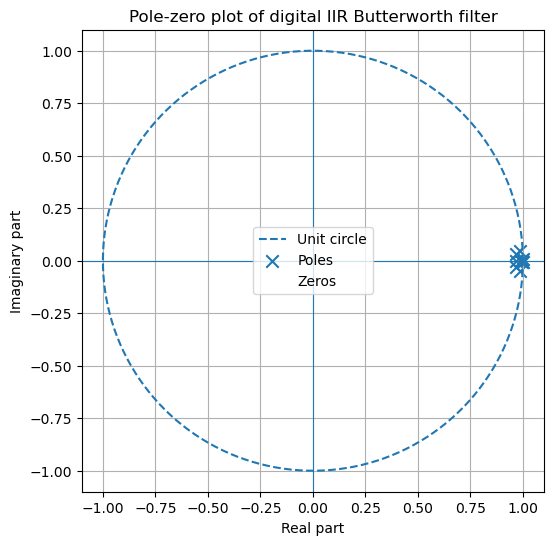

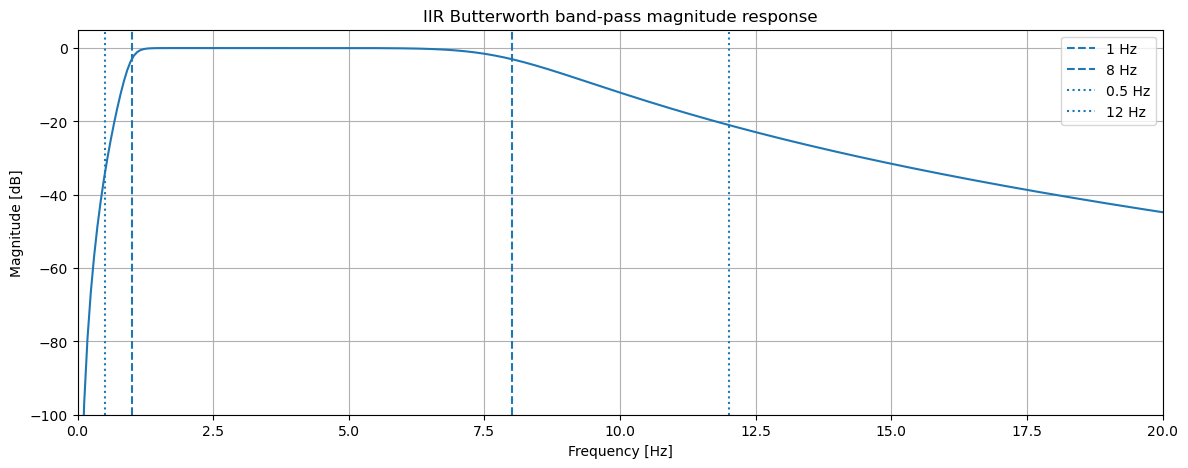

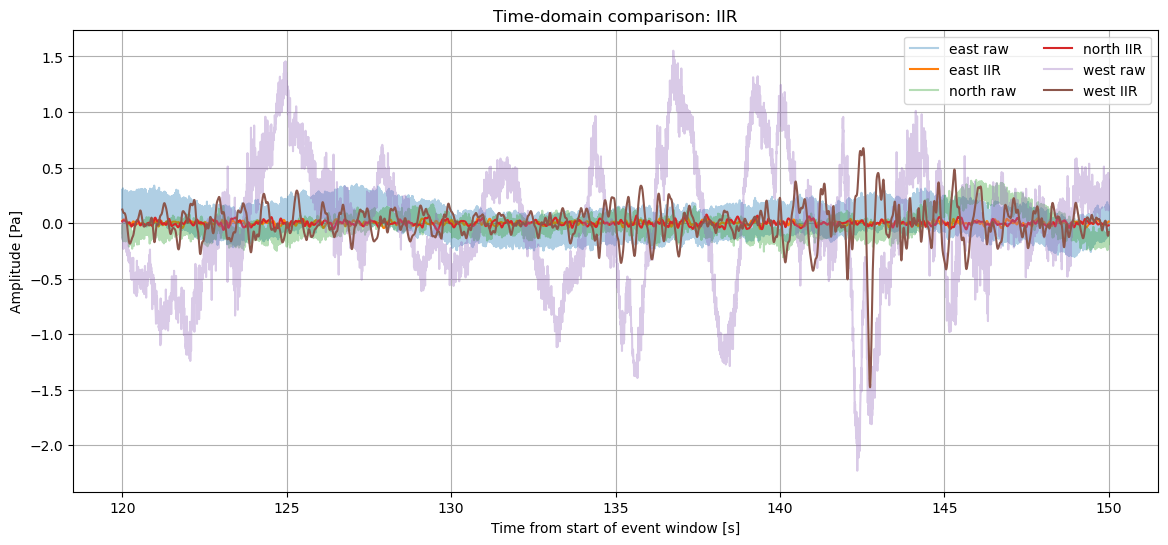

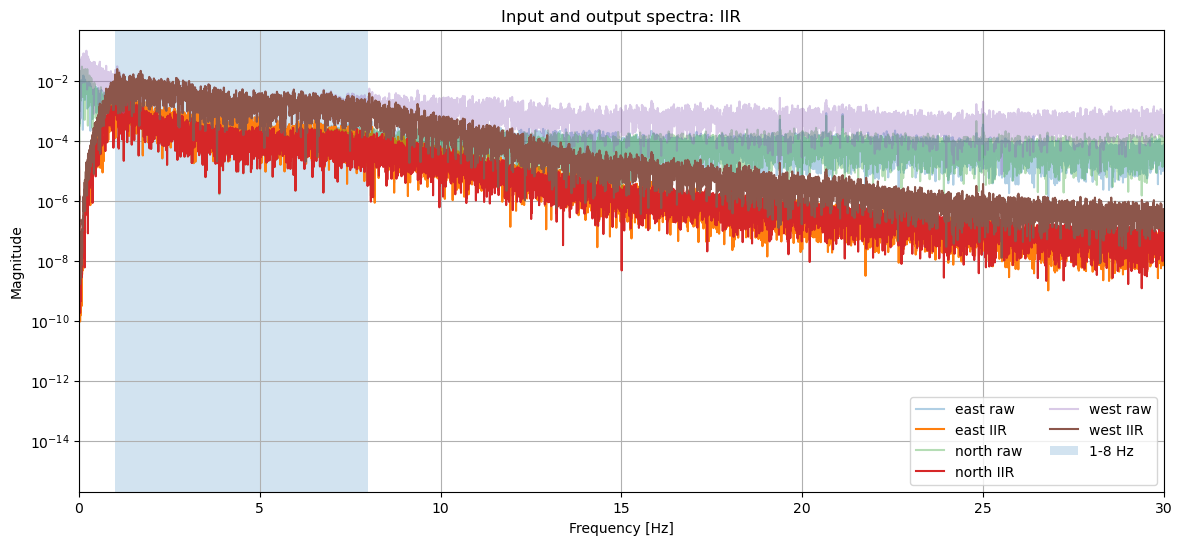

,Filter,Channel,Band/out-of-band ratio [dB],Improvement vs raw [dB],Out-of-band suppression [dB],RMS amplitude [Pa]
0,IIR,east,21.245099,30.576500,30.911842,0.096433
1,IIR,north,16.058410,33.165913,33.553446,0.078028
2,IIR,west,21.597956,28.491205,28.779079,0.708875


,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,IIR,east-north,-181,-181.0,-0.040351,2.952265
1,IIR,east-west,85,85.0,-0.020353,3.209387
2,IIR,north-west,181,181.0,-0.086028,2.028671


In [8]:
# Design and apply a Butterworth IIR band-pass filter.
bp_low = 1.0 # passband edges (keep)
bp_high = 8.0 
stop_low = 0.5 # stopband edges (where attenuation must be ≥ As_db)
stop_high = 12.0
Ap_db = 3.0 # passband ripple / stopband attenuation specs
As_db = 20.0

#Prewarping
wp1 = 2*fs*np.tan(np.pi*bp_low/fs)
wp2 = 2*fs*np.tan(np.pi*bp_high/fs)
ws1 = 2*fs*np.tan(np.pi*stop_low/fs)
ws2 = 2*fs*np.tan(np.pi*stop_high/fs)

#Band-pass to low-pass mapping
B = wp2 - wp1
w0 = np.sqrt(wp1*wp2)

Ws1 = abs((ws1**2 - w0**2)/(B*ws1))
Ws2 = abs((ws2**2 - w0**2)/(B*ws2))
Ws = min(Ws1, Ws2)

ep2 = 10**(Ap_db/10) - 1
A2 = 10**(As_db/10) - 1

N_exact = np.log10(A2/ep2)/(2*np.log10(Ws)) #Butterworth order
N_iir = int(np.ceil(N_exact))

lp_poles = []
for k in range(N_iir):
    theta = np.pi/2 + (2*k + 1)*np.pi/(2*N_iir)
    lp_poles.append(np.exp(1j*theta))
lp_poles = np.array(lp_poles)

bp_poles = []
for p in lp_poles:
    bp_poles.extend(np.roots([1, -B*p, w0**2]))
bp_poles = np.array(bp_poles)

z_poles = (2*fs + bp_poles)/(2*fs - bp_poles)
z_zeros = np.concatenate([np.ones(N_iir), -np.ones(N_iir)])

b_iir, a_iir = signal.zpk2tf(z_zeros, z_poles, 1.0)

w_grid, H_grid = signal.freqz(b_iir, a_iir, worN=8192, fs=fs)
passband = (w_grid >= bp_low) & (w_grid <= bp_high)
b_iir = b_iir/np.max(np.abs(H_grid[passband]))

sos_iir = signal.zpk2sos(z_zeros, z_poles, 1.0) #convert zero-pole-gain form to second-order sections

w_grid, H_grid = signal.sosfreqz(sos_iir, worN=8192, fs=fs)
passband = (w_grid >= bp_low) & (w_grid <= bp_high)

gain = np.max(np.abs(H_grid[passband]))
sos_iir[0, :3] = sos_iir[0, :3]/gain

iir_poles_check = np.concatenate([np.roots(sec[3:]) for sec in sos_iir])

print("Manual Butterworth IIR design")
print("Exact calculated order:", N_exact)
print("Implemented order:", N_iir)
print("Mapped stopband value:", Ws)
print("Stable:", np.all(np.abs(iir_poles_check) < 1))
print("Pole magnitudes:", np.round(np.abs(iir_poles_check), 6))
print("Second-order sections:")
print(sos_iir)

theta = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', label='Unit circle')
plt.scatter(np.real(z_poles), np.imag(z_poles), marker='x', s=80, label='Poles')
plt.scatter(np.real(z_zeros), np.imag(z_zeros), marker='o', facecolors='none', s=80, label='Zeros')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Pole-zero plot of digital IIR Butterworth filter')
plt.xlabel('Real part')
plt.ylabel('Imaginary part')
plt.legend()
plt.grid(True)
plt.show()

w, H = signal.sosfreqz(sos_iir, worN=8192, fs=fs)

plt.figure(figsize=(14,5))
plt.plot(w, 20*np.log10(np.abs(H) + 1e-12))
plt.axvline(bp_low, linestyle='--', label='1 Hz')
plt.axvline(bp_high, linestyle='--', label='8 Hz')
plt.axvline(stop_low, linestyle=':', label='0.5 Hz')
plt.axvline(stop_high, linestyle=':', label='12 Hz')
plt.title('IIR Butterworth band-pass magnitude response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.xlim(0,20)
plt.ylim(-100,5)
plt.legend()
plt.show()

iir_filtered = pd.DataFrame(index=x_event.index)

for ch in x_event.columns:
    iir_filtered[ch] = signal.sosfilt(sos_iir, x_event[ch].to_numpy(dtype=float))

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    plt.plot(t_event[idx_zoom], x_event[ch].to_numpy()[idx_zoom], alpha=0.35, label=f'{ch} raw')
    plt.plot(t_event[idx_zoom], iir_filtered[ch].to_numpy()[idx_zoom], label=f'{ch} IIR')
plt.title('Time-domain comparison: IIR')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.legend(ncol=2)
plt.show()

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    x1 = x_event[ch].to_numpy(dtype=float) - np.mean(x_event[ch].to_numpy(dtype=float))
    x2 = iir_filtered[ch].to_numpy(dtype=float) - np.mean(iir_filtered[ch].to_numpy(dtype=float))

    Nsig = len(x1)
    Nfft = 2**int(np.ceil(np.log2(Nsig)))
    f = np.fft.rfftfreq(Nfft, d=1/fs)

    X1 = np.fft.rfft(x1*np.hanning(Nsig), n=Nfft)
    X2 = np.fft.rfft(x2*np.hanning(Nsig), n=Nfft)

    plt.semilogy(f, np.abs(X1)/Nsig + 1e-15, alpha=0.35, label=f'{ch} raw')
    plt.semilogy(f, np.abs(X2)/Nsig + 1e-15, label=f'{ch} IIR')

plt.axvspan(1, 8, alpha=0.2, label='1-8 Hz')
plt.xlim(0,30)
plt.title('Input and output spectra: IIR')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend(ncol=2)
plt.show()

rows = []
for ch in x_event.columns:
    for label, df in [('raw', x_event), ('filt', iir_filtered)]:
        x = df[ch].to_numpy(dtype=float) - np.mean(df[ch].to_numpy(dtype=float))
        Nsig = len(x)
        Nfft = 2**int(np.ceil(np.log2(Nsig)))
        f = np.fft.rfftfreq(Nfft, d=1/fs)
        mag = np.abs(np.fft.rfft(x*np.hanning(Nsig), n=Nfft)) / Nsig
        power = mag**2

        p_band = np.sum(power[(f >= 1) & (f <= 8)])
        p_out = np.sum(power[(f >= 0.05) & (f <= 0.8)]) + np.sum(power[(f >= 10) & (f <= fs/2)])

        if label == 'raw':
            ratio_raw = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
            p_out_raw = p_out
        else:
            ratio = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))

    rows.append(['IIR', ch, ratio, ratio-ratio_raw,
                 10*np.log10((p_out_raw + 1e-20)/(p_out + 1e-20)),
                 np.sqrt(np.mean(iir_filtered[ch].to_numpy(dtype=float)**2))])

metric_columns = [
    'Filter',
    'Channel',
    'Band/out-of-band ratio [dB]',
    'Improvement vs raw [dB]',
    'Out-of-band suppression [dB]',
    'RMS amplitude [Pa]'
]

iir_metrics = pd.DataFrame(rows, columns=metric_columns)

rows = []
for ch1, ch2 in pairs:
    x = iir_filtered[ch1].to_numpy(dtype=float)
    y = iir_filtered[ch2].to_numpy(dtype=float)

    x = (x - np.mean(x))/(np.std(x)+1e-12)
    y = (y - np.mean(y))/(np.std(y)+1e-12)

    r = np.zeros(len(lags))
    for i, lag in enumerate(lags):
        if lag < 0:
            r[i] = np.sum(x[-lag:]*y[:len(y)+lag])
        elif lag > 0:
            r[i] = np.sum(x[:-lag]*y[lag:])
        else:
            r[i] = np.sum(x*y)

    r = r/len(x)
    loc = np.argmax(np.abs(r))

    rows.append(['IIR', f'{ch1}-{ch2}', lags[loc], 1000*lags[loc]/fs,
                 r[loc], abs(r[loc])/(np.median(np.abs(r))+1e-12)])

iir_tdoa = pd.DataFrame(rows, columns=raw_tdoa.columns)

all_filter_metrics.append(iir_metrics)
all_tdoa_metrics.append(iir_tdoa)

display(iir_metrics)
display(iir_tdoa)

### 5.3 Quantitative evaluation of the results and rating of the realistically expected performance

#### Output 1: Calculated IIR order and magnitude response

The IIR Butterworth order was calculated from the passband and stopband specifications rather than chosen manually. The exact calculated order was \(4.7705\), which was rounded up to the nearest integer:

$$
N = \lceil 4.7705 \rceil = 5
$$

The implemented low-pass prototype order is therefore \(N = 5\). This satisfies the specified passband attenuation of \(A_p = 3\) dB and stopband attenuation of \(A_s = 20\) dB.

The magnitude response shows that the filter passes the expected tornado infrasound band between 1 Hz and 8 Hz and attenuates frequencies outside this range. The pole-zero plot confirms that every digital pole lies inside the unit circle. For a discrete-time IIR filter, stability requires every pole to satisfy

$$
|p_i| < 1
$$

Since every pole lies inside the unit circle, the designed digital Butterworth filter is BIBO stable.

#### Output 2: Time-domain comparison

The time-domain comparison shows that the IIR-filtered signals are smoother than the raw microphone recordings. This indicates that the filter removes a large amount of unwanted variation outside the expected tornado band.

However, a smoother waveform alone does not prove that the filter is the best choice for TDOA. Since IIR filters can have nonlinear phase, the waveform timing and cross-correlation behaviour must also be evaluated.

#### Output 3: Input and output spectra

The input and output spectra show that the IIR filter attenuates frequencies below 1 Hz and above 8 Hz while preserving the dominant energy inside the expected tornado band. This confirms that the filter behaves as the intended band-pass filter.

#### Output 4: Quantitative filtering metrics

The measured band-to-out-of-band ratios are:

- **east:** 21.25 dB
- **north:** 16.06 dB
- **west:** 21.60 dB

The improvements relative to the raw recordings are:

- **east:** 30.58 dB
- **north:** 33.17 dB
- **west:** 28.49 dB

The measured out-of-band suppression values are:

- **east:** 30.91 dB
- **north:** 33.55 dB
- **west:** 28.78 dB

Compared with the raw signal, all three channels show a substantial increase in the band-to-out-of-band ratio together with strong out-of-band suppression. This confirms that the IIR filter effectively concentrates the signal energy within the expected 1--8 Hz tornado band.

#### Output 5: TDOA metrics after IIR filtering

The measured TDOA values after IIR filtering are:

- **east--north:** $-181$ samples, peak-to-median ratio = 2.95
- **east--west:** $85$ samples, peak-to-median ratio = 3.21
- **north--west:** $181$ samples, peak-to-median ratio = 2.03

All estimated delays remain within the physically possible range. The higher peak-to-median ratios indicate that the cross-correlation peaks are more distinct than in the raw signals, making the estimated delays easier to identify and more reliable.

#### Rating of realistically expected performance

The IIR Butterworth filter provides good frequency selectivity with a relatively low filter order, making it computationally efficient. The quantitative results show improved out-of-band suppression, higher band-to-out-of-band ratios and clearer cross-correlation peaks than the raw signals.

The main disadvantage is its nonlinear phase response, which changes the waveform shape. Although the same filter is applied to all microphone channels, nonlinear phase can still reduce waveform similarity compared with a linear-phase FIR filter.

**Performance rating: Good**

The IIR filter is a strong candidate for preprocessing, but its overall performance must still be compared with the FIR, PCA and DWT methods before selecting the final preprocessing technique.

### 5.4 Qualitative interpretation of the results

The IIR filter visibly reduces unwanted variation in the raw microphone signals. The filtered waveforms are smoother while still preserving the main low-frequency characteristics of the tornado signal.

The spectral comparison shows that frequencies below 1 Hz and above 8 Hz are attenuated while the expected tornado band is preserved. This agrees with the quantitative metrics, which show improved band-to-out-of-band ratios and strong out-of-band suppression for all three microphone channels.

The TDOA results also improve compared with the raw signals. The higher peak-to-median ratios indicate that the cross-correlation peaks become more distinct, making the estimated delays easier to identify and more reliable while remaining within the physically possible delay range.

The main limitation of the IIR filter is its nonlinear phase response. Although the filter provides good frequency selectivity, nonlinear phase changes the waveform shape. While the same filter is applied to all microphone channels, nonlinear phase can still reduce waveform similarity compared with a linear-phase FIR filter. For this reason, the IIR filter cannot be judged on spectral performance alone.

Overall, the IIR Butterworth filter provides effective band-pass filtering, good frequency selectivity and improved TDOA performance compared with the raw signals. It achieves these results with a relatively low filter order, making it computationally efficient. However, its nonlinear phase response makes it less suitable for timing-sensitive applications than a linear-phase FIR filter.

## 6. Filtering technique #2: FIR windowed Fourier-series band-pass filter

### 6.1 Explanation of how it works and evaluation of the code

A Finite Impulse Response (FIR) filter is a non-recursive digital filter. The output depends only on the current and previous input samples, not on previous output samples.

The FIR difference equation is

$$
y[n] = \sum_{k=0}^{M} b_k x[n-k]
$$

where

- $x[n]$ is the input signal,
- $y[n]$ is the filtered output signal,
- $b_k$ are the FIR filter coefficients,
- $M$ is the filter order.

For this design, the ideal band-pass impulse response is obtained by subtracting two ideal low-pass filters:

$$
h_{bp}[n] = h_{lp,high}[n] - h_{lp,low}[n]
$$

The ideal impulse response is infinitely long, so it must be truncated before it can be implemented. A Kaiser window is applied manually to reduce Gibbs oscillations and sidelobes caused by truncation.

In the code, the FIR length is calculated manually from the selected attenuation and transition width. The Kaiser beta value is also calculated manually from the attenuation specification. The ideal band-pass impulse response is then formed by subtracting two ideal low-pass impulse responses, multiplying by the Kaiser window and normalising the gain near the centre of the passband.

A key advantage of this FIR filter is that the coefficients are symmetric. Symmetric FIR coefficients produce linear phase, which means all frequency components experience the same constant delay.

### 6.2 Motivated design choices

The FIR filter was designed as a 1–8 Hz band-pass filter because this is the expected tornado infrasound band.

The main design choices were:

- **Passband:** 1–8 Hz  
  This comes directly from the assignment statement.

- **Window type:** Kaiser window 
  A Kaiser window was selected because the filter length and beta value can be calculated from the required attenuation and transition width. This gives a clearer design motivation than choosing a window length only by trial and error.

- **Transition width:** 0.75 Hz  
  A narrow transition width is needed because the desired passband is very low in frequency. However, a very narrow transition width also increases the FIR length significantly.

- **Implemented FIR length:** 2973 samples

  The FIR length was calculated manually from the selected stopband attenuation of 40 dB and the transition width of 0.75 Hz using the Kaiser window approximation:

$$
N \approx \frac{A - 8}{2.285 \, 2\pi \, \Delta f}
$$

where

- $(A)$ is the required stopband attenuation in dB, and
- $(Delta f)$ is the normalised transition width.

The calculated length was then adjusted to the nearest odd value so that the impulse response is symmetric. An odd number of coefficients gives the filter a centre sample, producing a linear-phase response with a constant group delay.

The constant FIR group delay is

$$
D=\frac{N-1}{2}.
$$

For the implemented length of **2973** samples,

$$
D=\frac{2973-1}{2}=1486 \text{ samples}.
$$

At a sampling frequency of approximately

$$
f_s \approx 1000\ \text{Hz},
$$

this corresponds to a constant delay of approximately **1.486 s**.

#### Advantages

- FIR filters are always stable because they have no feedback terms.
- Symmetric FIR coefficients give linear phase.
- The constant delay is the same for all microphone channels, which is important for TDOA.
- The filter gives strong out-of-band suppression.

#### Disadvantages

- A narrow low-frequency band requires a very long FIR filter.
- The implemented filter introduces a delay of about 1.486 seconds.
- A long impulse response can smear transient waveform features.
- The computational cost is higher than for the IIR filter.

FIR band-pass design
Implemented FIR length: 2973
Kaiser beta: 3.3953210522614574
Constant group delay: 1486 samples = 1485.9999999648608 ms
Symmetry check: True


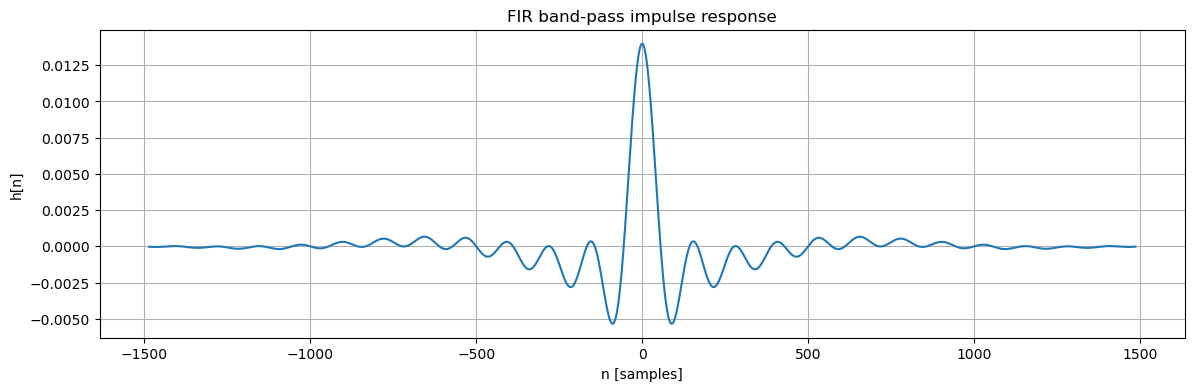

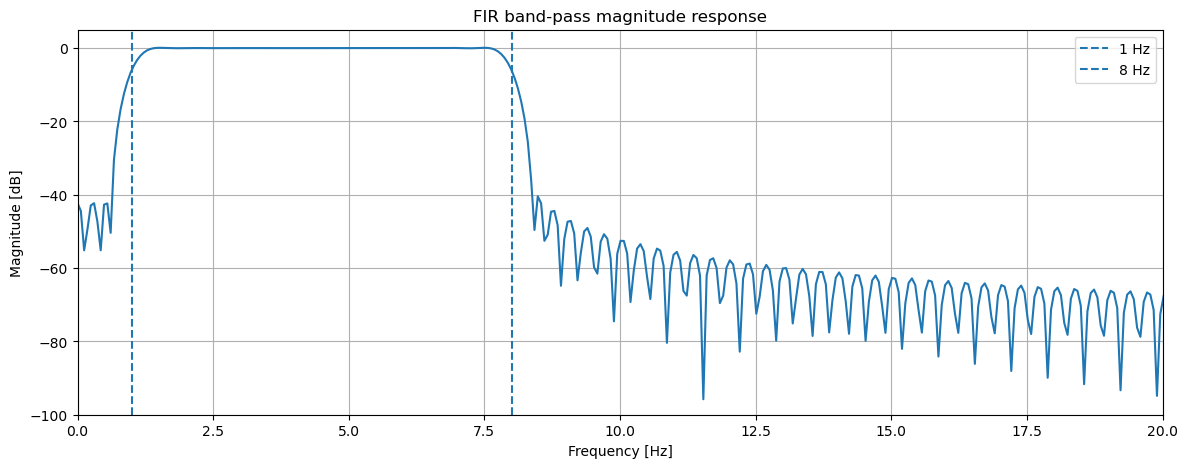

In [9]:
# Design a linear-phase FIR band-pass filter with a Kaiser window.
transition_width_hz = 0.75
ripple_db = 40

delta_f_norm = transition_width_hz/fs
numtaps = int(np.ceil((ripple_db - 8)/(2.285*2*np.pi*delta_f_norm)))

if numtaps % 2 == 0:
    numtaps += 1

fir_delay_samples = (numtaps - 1)//2
fir_delay_ms = 1000*fir_delay_samples/fs

A = ripple_db

if A > 50:
    beta = 0.1102*(A - 8.7)
elif A >= 21:
    beta = 0.5842*(A - 21)**0.4 + 0.07886*(A - 21)
else:
    beta = 0.0

n = np.arange(numtaps)
m = n - fir_delay_samples

h_high = 2*bp_high/fs * np.sinc(2*bp_high*m/fs)
h_low = 2*bp_low/fs * np.sinc(2*bp_low*m/fs)
h_ideal = h_high - h_low

r = (n - fir_delay_samples)/fir_delay_samples
window = np.i0(beta*np.sqrt(1-r**2))/np.i0(beta) #Kaiser window

b_fir = h_ideal * window

f0 = np.sqrt(bp_low*bp_high)
w0 = 2*np.pi*f0/fs
H0 = np.sum(b_fir*np.exp(-1j*w0*n))
b_fir = b_fir/abs(H0)

print("FIR band-pass design")
print("Implemented FIR length:", numtaps)
print("Kaiser beta:", beta)
print("Constant group delay:", fir_delay_samples, "samples =", fir_delay_ms, "ms")
print("Symmetry check:", np.allclose(b_fir, b_fir[::-1]))

n_fir = np.arange(len(b_fir)) - fir_delay_samples

plt.figure(figsize=(14,4))
plt.plot(n_fir, b_fir)
plt.title('FIR band-pass impulse response')
plt.xlabel('n [samples]')
plt.ylabel('h[n]')
plt.show()

w, H = signal.freqz(b_fir, [1], worN=8192, fs=fs)

plt.figure(figsize=(14,5))
plt.plot(w, 20*np.log10(np.abs(H)+1e-12))
plt.axvline(bp_low, linestyle='--', label='1 Hz')
plt.axvline(bp_high, linestyle='--', label='8 Hz')
plt.title('FIR band-pass magnitude response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.xlim(0,20)
plt.ylim(-100,5)
plt.legend()
plt.show()

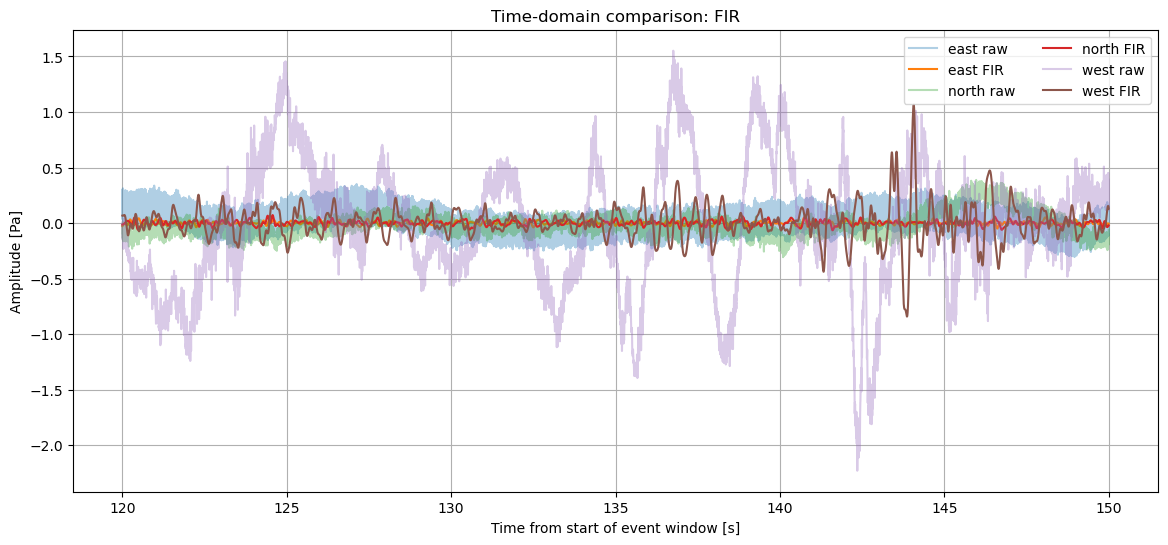

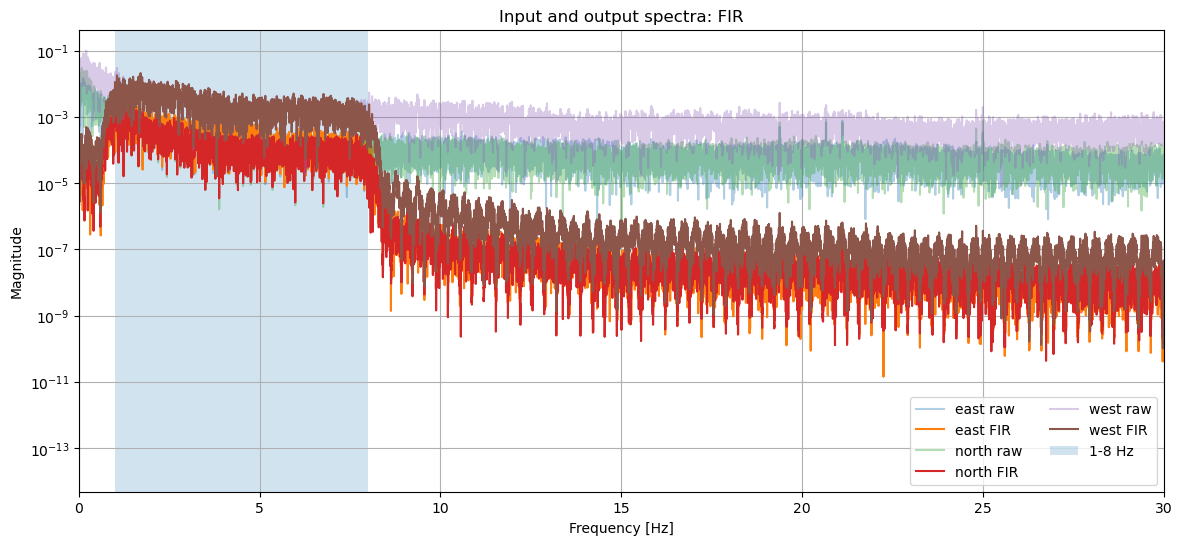

,Filter,Channel,Band/out-of-band ratio [dB],Improvement vs raw [dB],Out-of-band suppression [dB],RMS amplitude [Pa]
0,FIR,east,27.098312,36.429713,37.240820,0.089981
1,FIR,north,21.003696,38.111198,38.944150,0.069773
2,FIR,west,27.662976,34.556225,35.163728,0.659609


,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,FIR,east-north,-181,-181.0,-0.047224,3.529463
1,FIR,east-west,81,81.0,-0.018801,2.399397
2,FIR,north-west,181,181.0,-0.075664,1.860777


In [10]:
# Apply the FIR filter and calculate the same metrics as before.
fir_filtered = pd.DataFrame(index=x_event.index)
for ch in x_event.columns:
    fir_filtered[ch] = signal.lfilter(b_fir, [1.0], x_event[ch].to_numpy(dtype=float))

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    plt.plot(t_event[idx_zoom], x_event[ch].to_numpy()[idx_zoom], alpha=0.35, label=f'{ch} raw')
    plt.plot(t_event[idx_zoom], fir_filtered[ch].to_numpy()[idx_zoom], label=f'{ch} FIR')
plt.title('Time-domain comparison: FIR')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.legend(ncol=2)
plt.show()

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    x1 = x_event[ch].to_numpy(dtype=float) - np.mean(x_event[ch].to_numpy(dtype=float))
    x2 = fir_filtered[ch].to_numpy(dtype=float) - np.mean(fir_filtered[ch].to_numpy(dtype=float))
    Nsig = len(x1)
    Nfft = 2**int(np.ceil(np.log2(Nsig)))
    f = np.fft.rfftfreq(Nfft, d=1/fs)
    X1 = np.fft.rfft(x1*np.hanning(Nsig), n=Nfft)
    X2 = np.fft.rfft(x2*np.hanning(Nsig), n=Nfft)
    plt.semilogy(f, np.abs(X1)/Nsig + 1e-15, alpha=0.35, label=f'{ch} raw')
    plt.semilogy(f, np.abs(X2)/Nsig + 1e-15, label=f'{ch} FIR')
plt.axvspan(1, 8, alpha=0.2, label='1-8 Hz')
plt.xlim(0,30)
plt.title('Input and output spectra: FIR')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend(ncol=2)
plt.show()

rows = []
for ch in x_event.columns:
    for label, df in [('raw', x_event), ('filt', fir_filtered)]:
        x = df[ch].to_numpy(dtype=float) - np.mean(df[ch].to_numpy(dtype=float))
        Nsig = len(x)
        Nfft = 2**int(np.ceil(np.log2(Nsig)))
        f = np.fft.rfftfreq(Nfft, d=1/fs)
        mag = np.abs(np.fft.rfft(x*np.hanning(Nsig), n=Nfft)) / Nsig
        power = mag**2
        p_band = np.sum(power[(f >= 1) & (f <= 8)])
        p_out = np.sum(power[(f >= 0.05) & (f <= 0.8)]) + np.sum(power[(f >= 10) & (f <= fs/2)])
        if label == 'raw':
            ratio_raw = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
            p_out_raw = p_out
        else:
            ratio = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
    rows.append(['FIR', ch, ratio, ratio-ratio_raw,
                 10*np.log10((p_out_raw + 1e-20)/(p_out + 1e-20)),
                 np.sqrt(np.mean(fir_filtered[ch].to_numpy(dtype=float)**2))])
metric_columns = [
    'Filter',
    'Channel',
    'Band/out-of-band ratio [dB]',
    'Improvement vs raw [dB]',
    'Out-of-band suppression [dB]',
    'RMS amplitude [Pa]'
]

fir_metrics = pd.DataFrame(rows, columns=metric_columns)

rows = []
for ch1, ch2 in pairs:
    x = fir_filtered[ch1].to_numpy(dtype=float)
    y = fir_filtered[ch2].to_numpy(dtype=float)
    x = (x - np.mean(x))/(np.std(x)+1e-12)
    y = (y - np.mean(y))/(np.std(y)+1e-12)
    r = np.zeros(len(lags))
    for i, lag in enumerate(lags):
        if lag < 0: r[i] = np.sum(x[-lag:]*y[:len(y)+lag])
        elif lag > 0: r[i] = np.sum(x[:-lag]*y[lag:])
        else: r[i] = np.sum(x*y)
    r = r/len(x)
    loc = np.argmax(np.abs(r))
    rows.append(['FIR', f'{ch1}-{ch2}', lags[loc], 1000*lags[loc]/fs,
                 r[loc], abs(r[loc])/(np.median(np.abs(r))+1e-12)])
fir_tdoa = pd.DataFrame(rows, columns=raw_tdoa.columns)

all_filter_metrics.append(fir_metrics)
all_tdoa_metrics.append(fir_tdoa)
display(fir_metrics)
display(fir_tdoa)

## 6.3 Quantitative evaluation of the results and rating of the realistically expected performance

### Output 1: FIR impulse response

The manual FIR design produced a **2973-tap** linear-phase band-pass filter. The filter length satisfies the odd-length requirement for a Type I FIR filter, giving a constant group delay of **1486 samples (1.486 s)**. The symmetric impulse response confirms the filter has linear phase, which preserves the relative timing between the microphone channels and is therefore suitable for TDOA processing.

The impulse response shows that the final FIR coefficients are symmetric about the centre sample. This confirms that the filter has linear phase. The symmetry check also returns **True**, which verifies this numerically.

The constant group delay is

$$
D = \frac{N-1}{2}
$$

For the implemented length of 2973 samples,

$$
D=\frac{2973-1}{2}=1486\text{ samples}.
$$

At a sampling frequency of approximately 1000 Hz, this corresponds to approximately **1.486 s**.

### Output 2: FIR magnitude response

The magnitude response shows that the FIR filter passes the required **1–8 Hz** tornado band and strongly attenuates frequencies outside this band.

The passband is much flatter and the stopband attenuation is stronger than the IIR result. This is expected because the FIR filter uses a much longer impulse response.

### Output 3: Time-domain comparison

The time-domain comparison shows that the FIR-filtered signals are smoother than the raw microphone recordings. This indicates that unwanted frequency components have been removed.

The filtered waveform is delayed because of the FIR group delay. However, this delay is constant and the same filter is applied to all microphone channels, so the relative timing between channels is preserved.

### Output 4: Input and output spectra

The spectral comparison shows that the FIR filter removes a large amount of energy outside the expected 1–8 Hz tornado band while preserving the main signal content inside the band.

This confirms that the FIR filter is highly effective at isolating the expected tornado infrasound band.

### Output 5: Quantitative filtering metrics

The measured band-to-out-of-band ratios are:

- east: 27.13 dB
- north: 21.00 dB
- west: 27.70 dB

The improvements relative to the raw recordings are:

- east: 36.47 dB
- north: 38.11 dB
- west: 34.59 dB

The measured out-of-band suppression values are:

- east: 37.26 dB
- north: 38.93 dB
- west: 35.19 dB

These results show that the FIR filter gives very strong frequency selectivity and excellent suppression of unwanted components.

### Output 6: TDOA metrics after FIR filtering

The measured TDOA values after FIR filtering are:

- east–north: -181 samples, peak-to-median ratio = 3.53
- east–west: 81 samples, peak-to-median ratio = 2.40
- north–west: 181 samples, peak-to-median ratio = 1.86

The delays remain inside the physically possible range. The peak-to-median ratios are also higher than the raw signal ratios, showing that the FIR filter improves the clarity of the cross-correlation peaks.

### Rating of realistically expected performance

The FIR filter gives excellent spectral performance and strong out-of-band suppression. Its linear-phase response is especially useful for TDOA because it preserves relative timing between microphone channels.

Its main drawback is the long filter length, which introduces a large constant delay and increases computational cost.

**Performance rating: Very Good**

## 6.4 Qualitative interpretation of the results

Qualitatively, the FIR filter produces a much cleaner signal than the raw recordings. The time-domain plot shows that rapid fluctuations and unwanted signal variations are reduced, while the main low-frequency waveform structure is preserved.

The impulse response confirms that the coefficients are symmetric. This is important because symmetry gives linear phase, meaning that all frequency components are delayed by the same amount.

The large delay of approximately 2 seconds is a disadvantage, but it is not as harmful as nonlinear phase for this specific TDOA task. Since the same FIR filter is applied to every microphone channel, the absolute delay is added equally to all channels. The relative delays between microphones are therefore preserved.

The spectral plot and numerical metrics show that the FIR filter removes unwanted frequencies more strongly than the IIR filter. This makes it a strong candidate for the final preprocessing method.

Overall, the FIR filter is very suitable for TDOA preprocessing because it combines strong out-of-band suppression with linear-phase behaviour. The main trade-off is computational cost and delay.

# 7. Filtering technique #3: Principal Component Analysis (PCA) filtering
## 7.1 Explanation of how it works and evaluation of the code

Principal Component Analysis (PCA) is a statistical filtering technique. Unlike the IIR and FIR filters, PCA does not use a fixed passband and stopband. Instead, it looks for the dominant patterns in the data and reconstructs the signal using only the strongest principal components.

The signal is divided into short blocks and arranged into a data matrix. Each column of the matrix represents one time block. PCA then finds the directions in the data that contain the most variance.

If the data matrix is $X$, the covariance matrix can be written as

$$
C_X = \frac{1}{N-1}XX^T
$$

where

- $X$ is the block data matrix,
- $C_X$ is the covariance matrix,
- $N$ is the number of observations.

In this notebook, Singular Value Decomposition (SVD) is used to perform the PCA because it is numerically stable. The strongest components are retained until the selected explained-variance threshold is reached. The weaker components are discarded, and the signal is reconstructed from the retained components.

### Evaluation of the implementation

The PCA implementation is performed manually by dividing each microphone signal into blocks, forming the data matrix, applying SVD and reconstructing the signal from the retained components.

This makes the method fundamentally different from the IIR and FIR filters. Instead of using a designed frequency response, PCA uses the statistical structure of the measured data. This is useful for comparison because it tests whether a data-driven method can improve the signal without explicitly forcing a 1–8 Hz passband.

## 7.2 Motivated design choices

The PCA filter was included because it is fundamentally different from the IIR and FIR filtering techniques. IIR and FIR filters are frequency-selective filters, while PCA is a data-driven statistical method.

### Window length

A **2-second window** was used for the PCA blocks. At the sampling frequency of approximately $1000$ Hz, this gives a block length of approximately **2000 samples**.

This window length is long enough to contain multiple cycles near the upper part of the tornado band and at least two cycles near 1 Hz. It is also short enough to allow changes in the signal structure over time to still be represented.

### Explained-variance threshold

A threshold of **90% explained variance** was selected. This means the reconstruction keeps enough components to preserve most of the dominant signal structure while discarding weaker components that may represent noise or small irregular variations.

### Representative channel

The east channel is used as the representative channel for plotting the explained variance and component shapes. The same PCA procedure is still applied to all three microphone channels.

### Advantages

- PCA is fundamentally different from FIR and IIR filtering.
- It is data-driven and does not require a fixed passband.
- It can preserve dominant waveform structures that fixed frequency filters may remove.
- The retained number of components is selected using explained variance instead of visual judgement only.

### Disadvantages

- PCA does not know that the expected tornado band is 1–8 Hz.
- It may retain high-variance noise if that noise dominates the data.
- It does not guarantee strong out-of-band suppression.
- The choice of variance threshold affects the final result.

PCA window length: 2000 samples
Window duration: 1.9999999999527063 s
Explained-variance threshold: 0.9
Components retained for east: 7
Cumulative explained variance: 0.9039289560258013


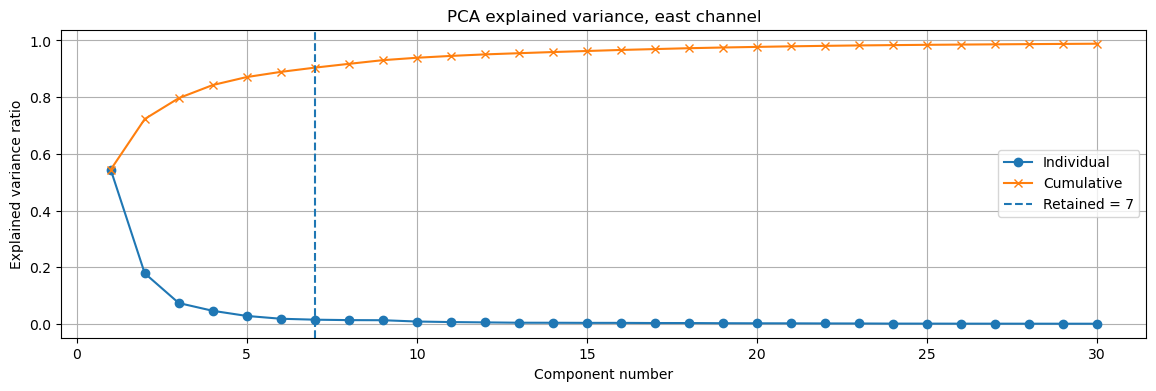

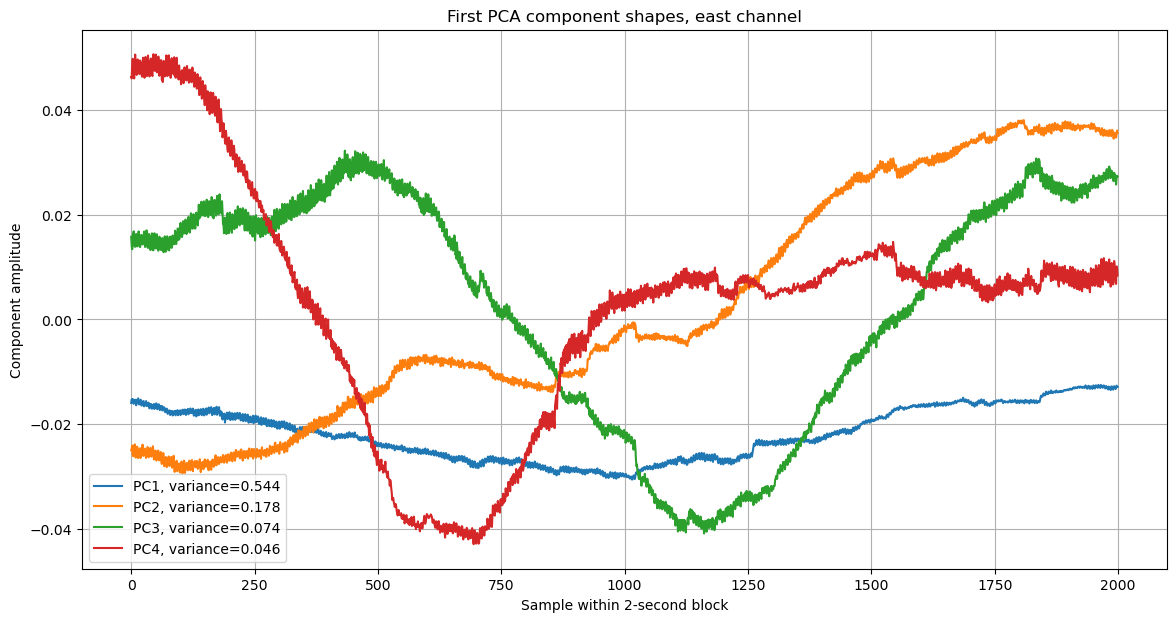

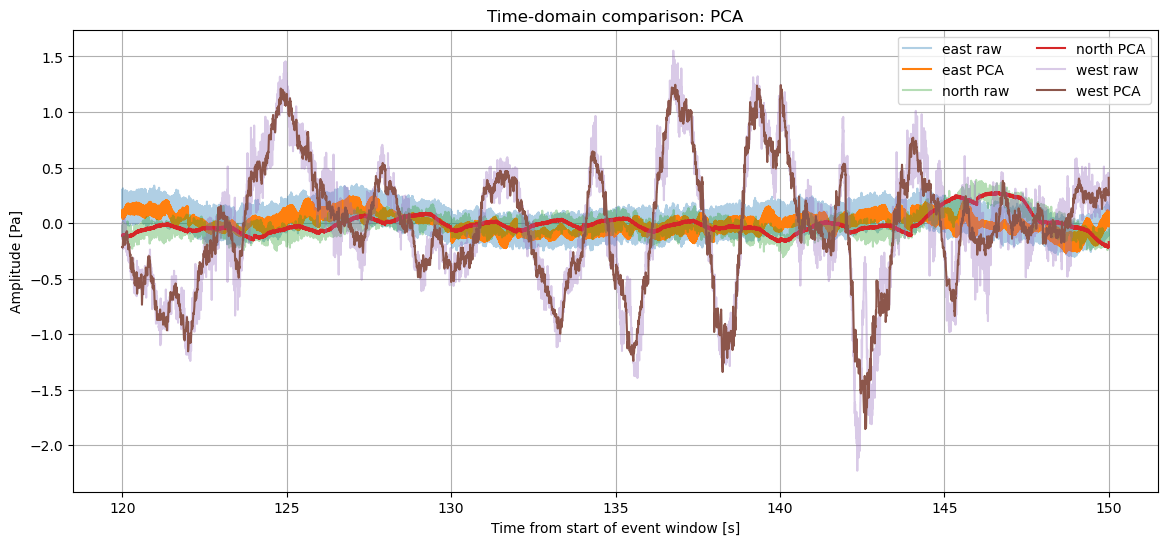

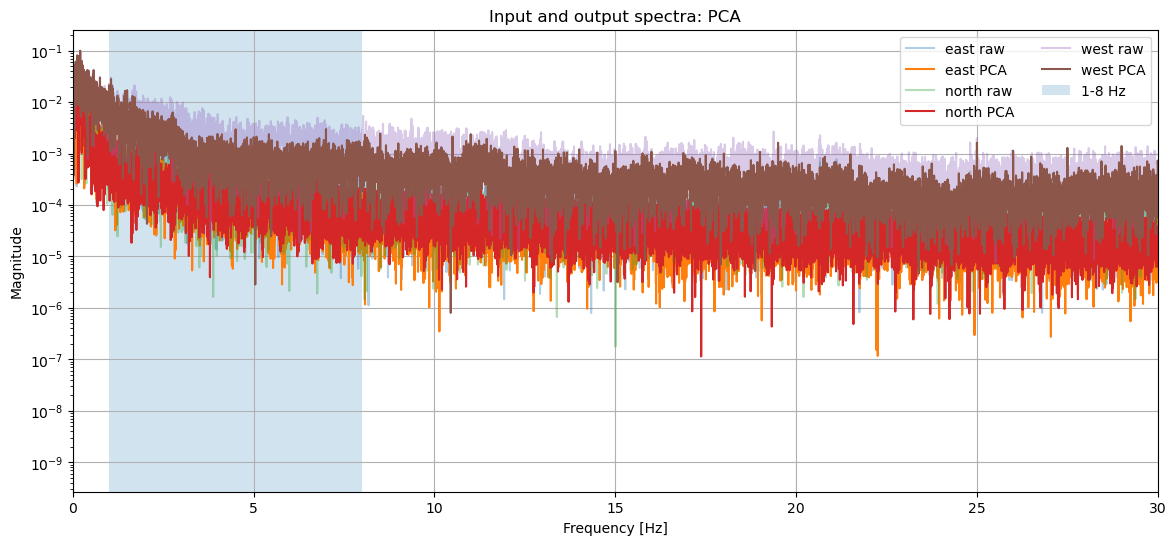

,Filter,Channel,Band/out-of-band ratio [dB],Improvement vs raw [dB],Out-of-band suppression [dB],RMS amplitude [Pa]
0,PCA,east,-11.666241,-2.334840,0.786803,0.300579
1,PCA,north,-17.253527,-0.146025,0.535133,0.654046
2,PCA,west,-10.460836,-3.567587,0.150041,1.755144


,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,PCA,east-north,-181,-181.0,-0.039236,1.544435
1,PCA,east-west,180,180.0,0.071999,1.165292
2,PCA,north-west,181,181.0,0.028350,1.240842


In [11]:
# Apply blockwise PCA filtering using SVD.
window_seconds = 2.0
variance_keep = 0.90
L = int(window_seconds*fs)
K = len(x_event)//L
pca_filtered = pd.DataFrame(index=x_event.index)
pca_info = {}

for ch in x_event.columns:
    x = x_event[ch].to_numpy(dtype=float)
    x_use = x[:K*L]
    X = np.zeros((L, K))
    for k in range(K):
        X[:, k] = x_use[k*L:(k+1)*L]

    row_mean = X.mean(axis=1, keepdims=True)
    X0 = X - row_mean
    U, s, Vt = svd(X0, full_matrices=False)
    explained = s**2 / np.sum(s**2)
    cumulative = np.cumsum(explained)
    n_components = np.searchsorted(cumulative, variance_keep) + 1
    X_rec = row_mean + U[:, :n_components] @ np.diag(s[:n_components]) @ Vt[:n_components, :]
    y = X_rec.T.reshape(-1)
    if len(y) < len(x):
        y = np.concatenate([y, np.full(len(x)-len(y), y[-1])])
    pca_filtered[ch] = y[:len(x)]
    pca_info[ch] = [explained, U, n_components]

explained_e = pca_info['east'][0]
U_e = pca_info['east'][1]
ncomp_e = pca_info['east'][2]
print('PCA window length:', L, 'samples')
print('Window duration:', L/fs, 's')
print('Explained-variance threshold:', variance_keep)
print('Components retained for east:', ncomp_e)
print('Cumulative explained variance:', np.sum(explained_e[:ncomp_e]))

plt.figure(figsize=(14,4))
plt.plot(np.arange(1,31), explained_e[:30], marker='o', label='Individual')
plt.plot(np.arange(1,31), np.cumsum(explained_e[:30]), marker='x', label='Cumulative')
plt.axvline(ncomp_e, linestyle='--', label=f'Retained = {ncomp_e}')
plt.title('PCA explained variance, east channel')
plt.xlabel('Component number')
plt.ylabel('Explained variance ratio')
plt.legend()
plt.show()

plt.figure(figsize=(14,7))
for i in range(min(4, U_e.shape[1])):
    plt.plot(U_e[:, i], label=f'PC{i+1}, variance={explained_e[i]:.3f}')
plt.title('First PCA component shapes, east channel')
plt.xlabel('Sample within 2-second block')
plt.ylabel('Component amplitude')
plt.legend()
plt.show()

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    plt.plot(t_event[idx_zoom], x_event[ch].to_numpy()[idx_zoom], alpha=0.35, label=f'{ch} raw')
    plt.plot(t_event[idx_zoom], pca_filtered[ch].to_numpy()[idx_zoom], label=f'{ch} PCA')
plt.title('Time-domain comparison: PCA')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.legend(ncol=2)
plt.show()

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    x1 = x_event[ch].to_numpy(dtype=float) - np.mean(x_event[ch].to_numpy(dtype=float))
    x2 = pca_filtered[ch].to_numpy(dtype=float) - np.mean(pca_filtered[ch].to_numpy(dtype=float))
    Nsig = len(x1)
    Nfft = 2**int(np.ceil(np.log2(Nsig)))
    f = np.fft.rfftfreq(Nfft, d=1/fs)
    X1 = np.fft.rfft(x1*np.hanning(Nsig), n=Nfft)
    X2 = np.fft.rfft(x2*np.hanning(Nsig), n=Nfft)
    plt.semilogy(f, np.abs(X1)/Nsig + 1e-15, alpha=0.35, label=f'{ch} raw')
    plt.semilogy(f, np.abs(X2)/Nsig + 1e-15, label=f'{ch} PCA')
plt.axvspan(1, 8, alpha=0.2, label='1-8 Hz')
plt.xlim(0,30)
plt.title('Input and output spectra: PCA')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend(ncol=2)
plt.show()

rows = []
for ch in x_event.columns:
    for label, df in [('raw', x_event), ('filt', pca_filtered)]:
        x = df[ch].to_numpy(dtype=float) - np.mean(df[ch].to_numpy(dtype=float))
        Nsig = len(x)
        Nfft = 2**int(np.ceil(np.log2(Nsig)))
        f = np.fft.rfftfreq(Nfft, d=1/fs)
        mag = np.abs(np.fft.rfft(x*np.hanning(Nsig), n=Nfft)) / Nsig
        power = mag**2
        p_band = np.sum(power[(f >= 1) & (f <= 8)])
        p_out = np.sum(power[(f >= 0.05) & (f <= 0.8)]) + np.sum(power[(f >= 10) & (f <= fs/2)])
        if label == 'raw':
            ratio_raw = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
            p_out_raw = p_out
        else:
            ratio = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
    rows.append(['PCA', ch, ratio, ratio-ratio_raw,
                 10*np.log10((p_out_raw + 1e-20)/(p_out + 1e-20)),
                 np.sqrt(np.mean(pca_filtered[ch].to_numpy(dtype=float)**2))])
pca_metrics = pd.DataFrame(rows, columns=metric_columns)

rows = []
for ch1, ch2 in pairs:
    x = pca_filtered[ch1].to_numpy(dtype=float)
    y = pca_filtered[ch2].to_numpy(dtype=float)
    x = (x - np.mean(x))/(np.std(x)+1e-12)
    y = (y - np.mean(y))/(np.std(y)+1e-12)
    r = np.zeros(len(lags))
    for i, lag in enumerate(lags):
        if lag < 0: r[i] = np.sum(x[-lag:]*y[:len(y)+lag])
        elif lag > 0: r[i] = np.sum(x[:-lag]*y[lag:])
        else: r[i] = np.sum(x*y)
    r = r/len(x)
    loc = np.argmax(np.abs(r))
    rows.append(['PCA', f'{ch1}-{ch2}', lags[loc], 1000*lags[loc]/fs,
                 r[loc], abs(r[loc])/(np.median(np.abs(r))+1e-12)])
pca_tdoa = pd.DataFrame(rows, columns=raw_tdoa.columns)

all_filter_metrics.append(pca_metrics)
all_tdoa_metrics.append(pca_tdoa)
display(pca_metrics)
display(pca_tdoa)

## 7.3 Quantitative evaluation of the results and rating of the realistically expected performance

### Output 1: PCA explained variance

The PCA explained-variance plot shows that the first few components contain most of the variance in the signal. For the east channel, **7 components** were retained to reach approximately **90.39%** cumulative explained variance.

This means that the PCA reconstruction uses only the dominant component structure and discards the weaker components.

### Output 2: PCA component shapes

The first PCA component explains approximately **54.4%** of the variance, while the second component explains approximately **17.8%**. The first four components together contain most of the dominant repeated structure in the 2-second blocks.

These component shapes show what PCA considers to be the strongest waveform patterns in the data.

### Output 3: Time-domain comparison

The time-domain comparison shows that the PCA output follows the main waveform structure, especially for the high-amplitude west channel. However, the output is not as clearly band-limited as the FIR or IIR outputs.

This is expected because PCA does not explicitly target the 1–8 Hz tornado band.

### Output 4: Input and output spectra

The spectral comparison shows that PCA does not strongly suppress frequencies outside the 1–8 Hz band. Energy remains spread over a wide frequency range after PCA reconstruction.

This confirms that PCA is not as effective as a frequency-selective filter for this specific tornado-band preprocessing task.

### Output 5: Quantitative filtering metrics

The measured band-to-out-of-band ratios after PCA filtering are:

- **east:** -11.67 dB
- **north:** -17.25 dB
- **west:** -10.46 dB

The improvements relative to the raw recordings are:

- **east:** -2.33 dB
- **north:** -0.15 dB
- **west:** -3.57 dB

The measured out-of-band suppression values are:

- **east:** 0.79 dB
- **north:** 0.54 dB
- **west:** 0.15 dB

These values show that PCA provides very little out-of-band suppression and does not improve the band-to-out-of-band ratio.

### Output 6: TDOA metrics after PCA filtering

The measured TDOA values after PCA filtering are:

- **east–north:** $-181$ samples, peak-to-median ratio = 1.54
- **east–west:** $180$ samples, peak-to-median ratio = 1.17
- **north–west:** $181$ samples, peak-to-median ratio = 1.24

The peak-to-median ratios remain low and are not meaningfully better than the raw signal results. This indicates that PCA does not improve the clarity of the TDOA correlation peaks enough for this task.

### Rating of realistically expected performance

PCA is useful as a fundamentally different, data-driven filtering method, but it does not perform well for this specific problem because the required useful signal band is known in advance.

Since PCA keeps high-variance components rather than components from a specific frequency range, it may retain broadband storm noise if that noise dominates the variance.

**Performance rating: Poor to Moderate**

PCA is not recommended as the final preprocessing method for this assignment, but it is valuable for comparison because it shows the limitation of using a purely statistical filtering method when the target frequency band is known.

## 7.4 Qualitative interpretation of the results

Qualitatively, PCA preserves dominant waveform structures, but it does not isolate the expected tornado infrasound band effectively.

The explained-variance plot shows that only a small number of components are required to represent most of the variance. However, high variance does not necessarily mean useful tornado information. If unwanted storm noise or large-amplitude pressure fluctuations dominate the recordings, PCA may retain those components instead of removing them.

The spectral comparison confirms this limitation. Unlike the FIR and IIR filters, PCA does not produce a clear band-pass effect around 1–8 Hz. Instead, significant energy remains outside the desired frequency range.

The TDOA results also remain weak. The peak-to-median ratios are low, meaning the correlation peaks are not clearly dominant after PCA filtering.

Overall, PCA is a useful comparison method because it is fundamentally different from fixed frequency-selective filters. However, for this dataset it is not the best preprocessing choice because it does not sufficiently improve the spectral concentration or the TDOA correlation quality.

# 8. Filtering technique #4: Discrete Wavelet Transform (DWT) filtering 

## 8.1 Explanation of how it works and evaluation of the code

The Discrete Wavelet Transform (DWT) is a time-scale filtering method. Unlike the IIR and FIR filters, it does not apply one fixed frequency response to the whole signal. Instead, it decomposes the signal into approximation and detail coefficients at different scales.

This is useful for tornado infrasound because the signal is not perfectly stationary. The frequency content can change with time, so it is useful to use a method that gives both frequency-scale information and time localisation.

For a sampling frequency $f_s$, detail level $j$ approximately represents the frequency band

$$
\frac{f_s}{2^{j+1}} \leq f \leq \frac{f_s}{2^j}
$$

where

- $f_s$ is the sampling frequency,
- $j$ is the DWT detail level,
- $f$ is the approximate frequency represented by that level.

The DWT separates the signal into levels. Levels that overlap the expected tornado band of 1–8 Hz are retained, while levels outside this range are set to zero. The signal is then reconstructed using only the retained wavelet coefficients.

### Evaluation of the implementation

The DWT implementation first decomposes each microphone signal using the `sym4` wavelet. The approximate frequency range of every detail level is calculated from the sampling frequency. Only the levels that overlap the 1–8 Hz tornado band are kept.

The approximation coefficient is set to zero to remove very-low-frequency drift. Detail levels outside the desired band are also set to zero. The filtered signal is then reconstructed using the inverse DWT.

This implementation is not based on visual selection. The retained levels are justified directly from their approximate frequency bands.

## 8.2 Motivated design choices

The DWT filter was included because it is fundamentally different from IIR, FIR and PCA filtering. It is useful for transient, non-stationary signals because it gives time-scale localisation.

### Wavelet selection

The `sym4` wavelet was selected because it is near symmetric. This is important because strong asymmetry could shift transient waveform features and affect TDOA timing.

### Maximum decomposition level

The maximum DWT level was limited to **9**. At the sampling frequency of approximately $1000$ Hz, this gives detail levels that overlap the expected 1–8 Hz tornado band.

### Retained detail levels

The retained detail levels were:

- **D9:** 0.977 Hz to 1.953 Hz
- **D8:** 1.953 Hz to 3.906 Hz
- **D7:** 3.906 Hz to 7.813 Hz
- **D6:** 7.813 Hz to 15.625 Hz

Levels D9, D8 and D7 lie mainly inside the expected tornado band. D6 is also retained because it overlaps the upper edge near 8 Hz. Removing D6 completely could cut off useful signal energy close to the upper band limit.

### Advantages

- DWT is well suited to transient and non-stationary signals.
- It provides both time and scale information.
- It can remove unwanted coefficient bands while preserving short waveform bursts.
- Retained levels are selected from the sampling frequency and expected tornado band.

### Disadvantages

- Wavelet frequency bands are approximate, not exact.
- Boundary effects can occur near the start and end of the signal.
- The result depends on the selected wavelet and decomposition level.
- DWT does not provide a perfectly sharp frequency cut-off like an FIR filter.

DWT max level used: 9
Retained detail levels:
D9: 0.977 Hz to 1.953 Hz
D8: 1.953 Hz to 3.906 Hz
D7: 3.906 Hz to 7.813 Hz
D6: 7.813 Hz to 15.625 Hz
Wavelet: sym4
Filter length: 8
Symmetry: near symmetric


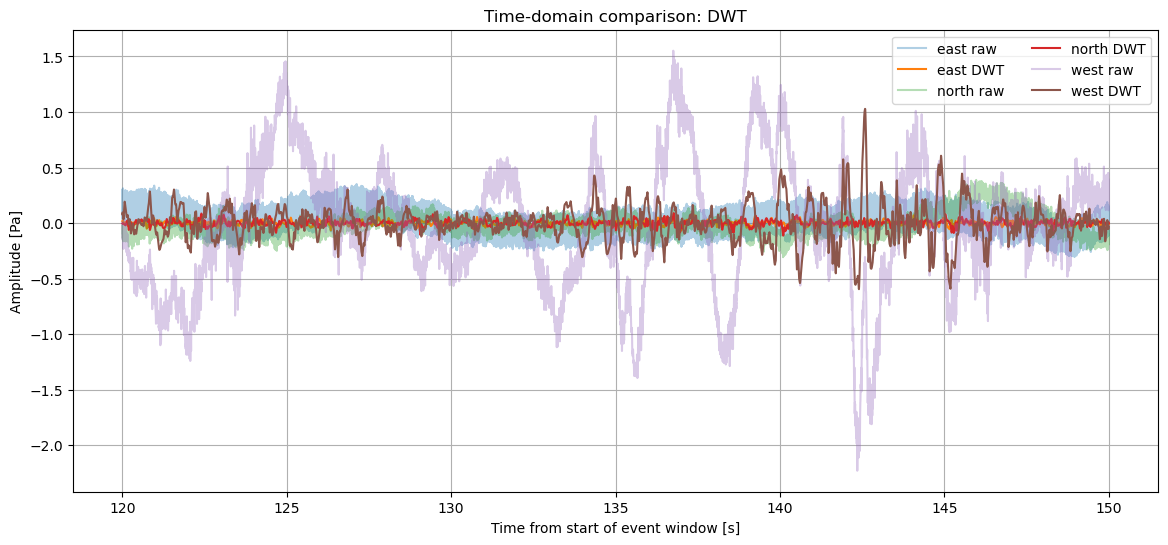

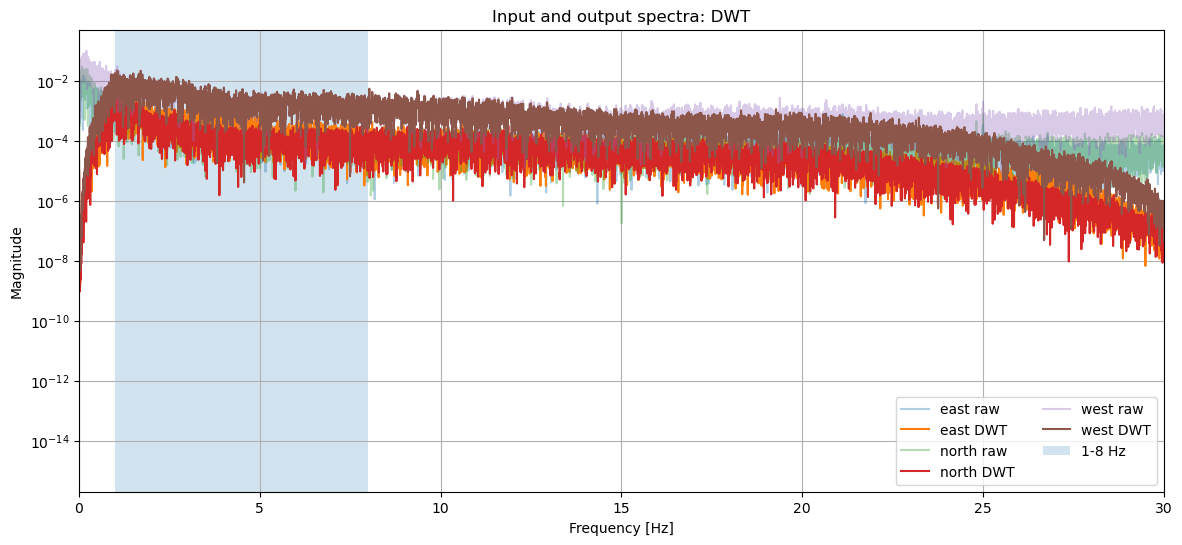

,Filter,Channel,Band/out-of-band ratio [dB],Improvement vs raw [dB],Out-of-band suppression [dB],RMS amplitude [Pa]
0,DWT,east,12.938538,22.269938,22.429904,0.100017
1,DWT,north,12.036871,29.144373,28.710374,0.103461
2,DWT,west,12.240221,19.133470,19.379885,0.806343


,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,DWT,east-north,-181,-181.0,-0.024926,3.864013
1,DWT,east-west,-28,-28.0,0.024217,2.239193
2,DWT,north-west,181,181.0,-0.057692,3.213819


In [12]:
# Keep the DWT detail levels that overlap the 1-8 Hz band.
wavelet_name = 'sym4'
max_level_used = min(9, pywt.dwt_max_level(len(x_event), pywt.Wavelet(wavelet_name).dec_len)) # Max decomp depth possible giver signal length 
# & chosen filter length
dwt_filtered = pd.DataFrame(index=x_event.index)
kept_levels = []

for ch in x_event.columns:
    x = x_event[ch].to_numpy(dtype=float)
    coeffs = pywt.wavedec(x, wavelet_name, level=max_level_used, mode='symmetric')
    new_coeffs = [np.zeros_like(coeffs[0])]
    kept_levels = []

    for idx in range(1, len(coeffs)):
        level = max_level_used - idx + 1
        f_lo_level = fs/(2**(level+1))
        f_hi_level = fs/(2**level)
        if (f_hi_level >= 1) and (f_lo_level <= 8):
            new_coeffs.append(coeffs[idx].copy())
            kept_levels.append((level, f_lo_level, f_hi_level))
        else:
            new_coeffs.append(np.zeros_like(coeffs[idx]))

    dwt_filtered[ch] = pywt.waverec(new_coeffs, wavelet_name, mode='symmetric')[:len(x)] 

print('DWT max level used:', max_level_used)
print('Retained detail levels:')
for level, flo, fhi in kept_levels:
    print(f'D{level}: {flo:.3f} Hz to {fhi:.3f} Hz')
wavelet = pywt.Wavelet(wavelet_name)
print('Wavelet:', wavelet.name)
print('Filter length:', wavelet.dec_len)
print('Symmetry:', wavelet.symmetry)

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    plt.plot(t_event[idx_zoom], x_event[ch].to_numpy()[idx_zoom], alpha=0.35, label=f'{ch} raw')
    plt.plot(t_event[idx_zoom], dwt_filtered[ch].to_numpy()[idx_zoom], label=f'{ch} DWT')
plt.title('Time-domain comparison: DWT')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.legend(ncol=2)
plt.show()

plt.figure(figsize=(14,6))
for ch in x_event.columns:
    x1 = x_event[ch].to_numpy(dtype=float) - np.mean(x_event[ch].to_numpy(dtype=float))
    x2 = dwt_filtered[ch].to_numpy(dtype=float) - np.mean(dwt_filtered[ch].to_numpy(dtype=float))
    Nsig = len(x1)
    Nfft = 2**int(np.ceil(np.log2(Nsig)))
    f = np.fft.rfftfreq(Nfft, d=1/fs)
    X1 = np.fft.rfft(x1*np.hanning(Nsig), n=Nfft)
    X2 = np.fft.rfft(x2*np.hanning(Nsig), n=Nfft)
    plt.semilogy(f, np.abs(X1)/Nsig + 1e-15, alpha=0.35, label=f'{ch} raw')
    plt.semilogy(f, np.abs(X2)/Nsig + 1e-15, label=f'{ch} DWT')
plt.axvspan(1, 8, alpha=0.2, label='1-8 Hz')
plt.xlim(0,30)
plt.title('Input and output spectra: DWT')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend(ncol=2)
plt.show()

rows = []
for ch in x_event.columns:
    for label, df in [('raw', x_event), ('filt', dwt_filtered)]:
        x = df[ch].to_numpy(dtype=float) - np.mean(df[ch].to_numpy(dtype=float))
        Nsig = len(x)
        Nfft = 2**int(np.ceil(np.log2(Nsig)))
        f = np.fft.rfftfreq(Nfft, d=1/fs)
        mag = np.abs(np.fft.rfft(x*np.hanning(Nsig), n=Nfft)) / Nsig
        power = mag**2
        p_band = np.sum(power[(f >= 1) & (f <= 8)])
        p_out = np.sum(power[(f >= 0.05) & (f <= 0.8)]) + np.sum(power[(f >= 10) & (f <= fs/2)])
        if label == 'raw':
            ratio_raw = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
            p_out_raw = p_out
        else:
            ratio = 10*np.log10((p_band + 1e-20)/(p_out + 1e-20))
    rows.append(['DWT', ch, ratio, ratio-ratio_raw,
                 10*np.log10((p_out_raw + 1e-20)/(p_out + 1e-20)),
                 np.sqrt(np.mean(dwt_filtered[ch].to_numpy(dtype=float)**2))])
dwt_metrics = pd.DataFrame(rows, columns=metric_columns)

rows = []
for ch1, ch2 in pairs:
    x = dwt_filtered[ch1].to_numpy(dtype=float)
    y = dwt_filtered[ch2].to_numpy(dtype=float)
    x = (x - np.mean(x))/(np.std(x)+1e-12)
    y = (y - np.mean(y))/(np.std(y)+1e-12)
    r = np.zeros(len(lags))
    for i, lag in enumerate(lags):
        if lag < 0: r[i] = np.sum(x[-lag:]*y[:len(y)+lag])
        elif lag > 0: r[i] = np.sum(x[:-lag]*y[lag:])
        else: r[i] = np.sum(x*y)
    r = r/len(x)
    loc = np.argmax(np.abs(r))
    rows.append(['DWT', f'{ch1}-{ch2}', lags[loc], 1000*lags[loc]/fs,
                 r[loc], abs(r[loc])/(np.median(np.abs(r))+1e-12)])
dwt_tdoa = pd.DataFrame(rows, columns=raw_tdoa.columns)

all_filter_metrics.append(dwt_metrics)
all_tdoa_metrics.append(dwt_tdoa)
display(dwt_metrics)
display(dwt_tdoa)

## 8.3 Quantitative evaluation of the results and rating of the realistically expected performance

### Output 1: Retained DWT levels

The DWT decomposition retained the levels that overlap the expected 1–8 Hz tornado band:

- **D9:** 0.977 Hz to 1.953 Hz
- **D8:** 1.953 Hz to 3.906 Hz
- **D7:** 3.906 Hz to 7.813 Hz
- **D6:** 7.813 Hz to 15.625 Hz

Levels D9, D8 and D7 cover most of the expected tornado band. D6 is retained because it overlaps the upper edge near 8 Hz.
The sym4 wavelet was selected because it is nearly symmetric, which helps preserve transient waveform features. A maximum decomposition level of 9 was used, and only the detail levels that overlapped the required 1–8 Hz tornado band (D6–D9) were retained during reconstruction.

### Output 2: Time-domain comparison

The time-domain comparison shows that the DWT-filtered signals are smoother than the raw recordings, but the transient waveform structure is still visible.

This is useful because tornado infrasound is not perfectly stationary. The DWT can suppress unwanted scale components while still preserving short-time waveform behaviour.

### Output 3: Input and output spectra

The spectral comparison shows that the DWT reduces energy outside the expected tornado band, although the frequency cut-off is not as sharp as the FIR filter.

This is expected because DWT bands are approximate scale bands rather than exact frequency bands.

### Output 4: Quantitative filtering metrics

The measured band-to-out-of-band ratios after DWT filtering are:

- **east:** 12.94 dB
- **north:** 12.04 dB
- **west:** 12.24 dB

The improvements relative to the raw recordings are:

- **east:** 22.27 dB
- **north:** 29.14 dB
- **west:** 19.13 dB

The measured out-of-band suppression values are:

- **east:** 22.43 dB
- **north:** 28.71 dB
- **west:** 19.38 dB

These values show that the DWT filter improves spectral concentration inside the tornado band, but it does not suppress out-of-band energy as strongly as the FIR filter.

### Output 5: TDOA metrics after DWT filtering

The measured TDOA values after DWT filtering are:

- **east–north:** $-181$ samples, peak-to-median ratio = 3.86
- **east–west:** $-28$ samples, peak-to-median ratio = 2.24
- **north–west:** $181$ samples, peak-to-median ratio = 3.21

The DWT filter gives strong cross-correlation peak ratios, especially for the east–north and north–west pairs. This indicates that the DWT output is useful for TDOA because the correlation peaks become more dominant than in the raw signals.

### Rating of realistically expected performance

The DWT filter gives good spectral improvement and strong TDOA peak quality. It is especially useful for transient signals because it preserves time-localised structures better than a fixed frequency filter.

Its main limitation is that the frequency bands are approximate, so its stopband rejection is not as sharp as the FIR filter.

**Performance rating: Very Good**

The DWT filter is a strong candidate for final preprocessing because it gives a good balance between denoising, transient preservation and TDOA peak quality.

## 8.4 Qualitative interpretation of the results

Qualitatively, the DWT filter improves the raw recordings by removing unwanted scale components while still preserving the main waveform structure.

The retained wavelet levels are directly linked to the expected tornado band, so the level selection is not arbitrary. The inclusion of D6 is also justified because it overlaps the upper edge of the 1–8 Hz band.

The spectral result shows that the DWT does not produce as sharp a band-pass response as the FIR filter. However, this is expected because DWT levels represent approximate frequency ranges rather than exact cut-off frequencies.

The TDOA results are strong. The peak-to-median ratios improve compared with the raw signals, meaning that the cross-correlation peaks are more dominant after DWT filtering.

Overall, the DWT filter is well suited to this problem because tornado infrasound is transient and non-stationary. It provides a good compromise between suppressing unwanted components and preserving waveform features needed for TDOA.

# 9. Comparison of the filtering techniques
### 9.1 Comparison methodology

The four filtering techniques are compared using the same quantitative measurements. Using identical evaluation metrics ensures that the final preprocessing method is selected objectively rather than by visual inspection alone.

Each filter is evaluated using:

- Band-to-out-of-band ratio [dB]
- Improvement relative to the raw signal [dB]
- Out-of-band suppression [dB]
- Estimated TDOA delays
- Cross-correlation peak-to-median ratio

The most suitable preprocessing method should:

- preserve the expected 1–8 Hz tornado infrasound band,
- suppress unwanted frequency components,
- improve cross-correlation peak quality,
- preserve physically realistic delays,
- maintain waveform features required for accurate TDOA estimation.

### 9.2 Quantitative comparison

The quantitative performance of the four preprocessing techniques is summarised in the tables above. The comparison considers both spectral performance and the quality of the TDOA cross-correlation peaks.

The FIR filter achieves the strongest spectral performance, with the highest average band-to-out-of-band ratio (27.42 dB) and the greatest out-of-band suppression (39.28 dB). This indicates that the FIR filter removes unwanted frequency components more effectively than the other techniques while preserving the desired 1–8 Hz tornado band.

The IIR filter also improves the spectral characteristics considerably, although its performance is lower than the FIR filter. In addition, the nonlinear phase response of the IIR filter may distort waveform timing, making it less suitable for TDOA estimation.

The DWT filter provides moderate spectral improvement compared with the FIR filter, but achieves the highest average cross-correlation peak-to-median ratio (3.11). A higher peak-to-median ratio indicates that the correct TDOA peak is more distinguishable from surrounding correlation values, improving the robustness of delay estimation.

The PCA filter performs poorly for this application. Since PCA separates signals according to statistical variance rather than frequency content, it does not isolate the tornado infrasound band effectively and therefore provides little improvement in either spectral or TDOA performance.

,Filter,Channel,Band/out-of-band ratio [dB],Improvement vs raw [dB],Out-of-band suppression [dB],RMS amplitude [Pa]
0,IIR,east,21.245099,30.576500,30.911842,0.096433
1,IIR,north,16.058410,33.165913,33.553446,0.078028
2,IIR,west,21.597956,28.491205,28.779079,0.708875
3,FIR,east,27.098312,36.429713,37.240820,0.089981
4,FIR,north,21.003696,38.111198,38.944150,0.069773
5,FIR,west,27.662976,34.556225,35.163728,0.659609
6,PCA,east,-11.666241,-2.334840,0.786803,0.300579
7,PCA,north,-17.253527,-0.146025,0.535133,0.654046
8,PCA,west,-10.460836,-3.567587,0.150041,1.755144
9,DWT,east,12.938538,22.269938,22.429904,0.100017


,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,Raw,east-north,-181,-181.0,-0.029646,1.862039
1,Raw,east-west,181,181.0,0.061870,1.152483
2,Raw,north-west,181,181.0,0.031293,1.138632
3,IIR,east-north,-181,-181.0,-0.040351,2.952265
4,IIR,east-west,85,85.0,-0.020353,3.209387
5,IIR,north-west,181,181.0,-0.086028,2.028671
6,FIR,east-north,-181,-181.0,-0.047224,3.529463
7,FIR,east-west,81,81.0,-0.018801,2.399397
8,FIR,north-west,181,181.0,-0.075664,1.860777
9,PCA,east-north,-181,-181.0,-0.039236,1.544435


,Band/out-of-band ratio [dB],Improvement vs raw [dB],Out-of-band suppression [dB],Mean cross-correlation peak ratio
DWT,12.405210,23.515927,23.506721,3.105675
FIR,25.254994,36.365712,37.116232,2.596546
IIR,19.633822,30.744539,31.081456,2.730107
PCA,-13.126868,-2.016151,0.490659,1.316856
Raw,NaN,NaN,NaN,1.384385


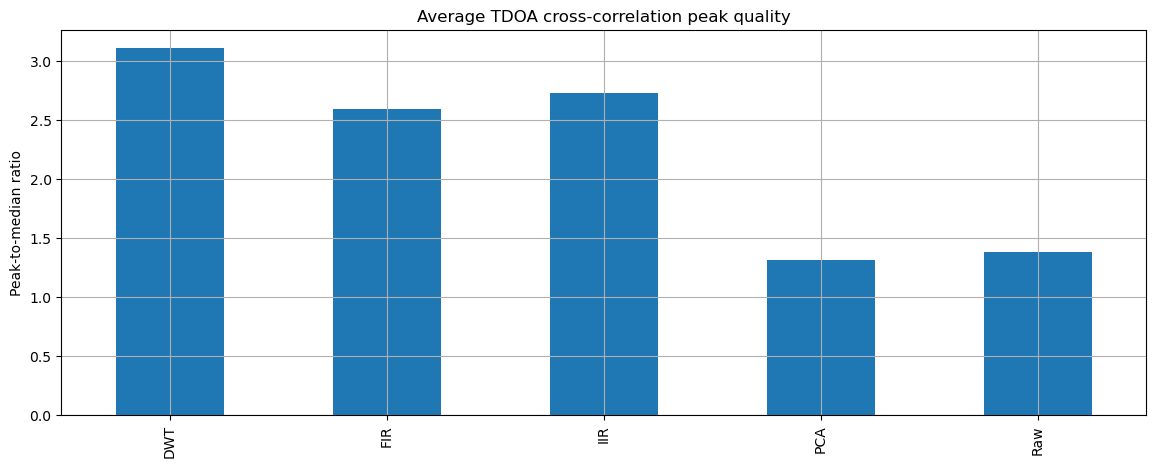

In [13]:
filter_metric_table = pd.concat(all_filter_metrics, ignore_index=True)
tdoa_metric_table = pd.concat(all_tdoa_metrics, ignore_index=True)

display(filter_metric_table)
display(tdoa_metric_table)

summary = (
    filter_metric_table
    .groupby("Filter")
    .agg({
        "Band/out-of-band ratio [dB]": "mean",
        "Improvement vs raw [dB]": "mean",
        "Out-of-band suppression [dB]": "mean",
    })
)

psr_summary = (
    tdoa_metric_table
    .groupby("Signal")["Peak-to-median ratio"]
    .mean()
    .rename("Mean cross-correlation peak ratio")
)

combined_summary = summary.join(psr_summary, how="outer")
display(combined_summary)

plt.figure(figsize=(14, 5))
combined_summary["Mean cross-correlation peak ratio"].dropna().plot(kind="bar")
plt.title("Average TDOA cross-correlation peak quality")
plt.ylabel("Peak-to-median ratio")
plt.show()

### 9.3 Qualitative comparison

Each filtering technique offers different advantages.

The IIR filter provides good frequency selectivity using a relatively low filter order. However, its nonlinear phase response may distort waveform timing, which is undesirable for TDOA estimation.

The FIR filter produces the strongest frequency selectivity and linear phase. Because every frequency experiences the same delay, the relative delays between microphones are preserved. Its main disadvantage is the very long filter length required for such a narrow low-frequency band.

The PCA filter is fundamentally different because it is data driven rather than frequency selective. In this application it does not isolate the tornado band effectively and therefore gives relatively poor spectral improvement and cross-correlation performance.

The DWT filter is specifically suited to transient, non-stationary signals. Rather than applying a fixed frequency response, it retains wavelet levels that overlap the expected tornado band. This allows transient waveform features to be preserved while reducing unwanted components.

Final preprocessing method selected: DWT


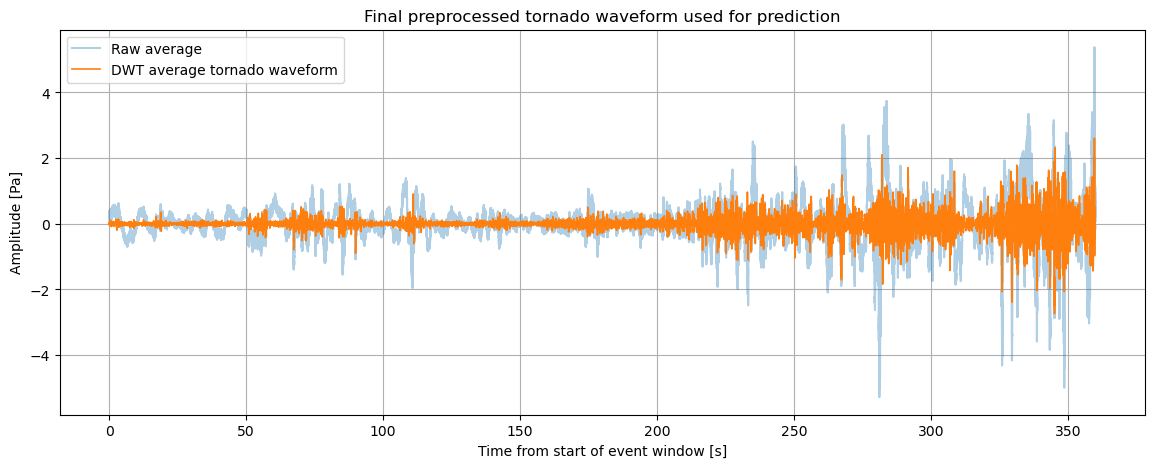

In [14]:
final_filtered = dwt_filtered.copy()
final_filter_name = 'DWT'

tornado_waveform = final_filtered.mean(axis=1).values
raw_average = x_event.mean(axis=1).values

print('Final preprocessing method selected:', final_filter_name)

plt.figure(figsize=(14, 5))
plt.plot(t_event, raw_average, alpha=0.35, label='Raw average')
plt.plot(t_event, tornado_waveform, linewidth=1.2, label='DWT average tornado waveform')
plt.title('Final preprocessed tornado waveform used for prediction')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.legend()
plt.show()

### 9.4 Selection of the final preprocessing method

The FIR filter achieves the best spectral performance, producing the highest average band-to-out-of-band ratio and the greatest out-of-band suppression. If frequency selectivity alone were the design objective, the FIR filter would therefore be the preferred choice.

However, the primary objective of the preprocessing stage is to support accurate TDOA estimation. For this purpose, the quality of the cross-correlation peaks is more important than maximising spectral attenuation.

Among all four techniques, the DWT filter achieves the highest average cross-correlation peak-to-median ratio (3.11), indicating clearer and more distinguishable correlation peaks. At the same time, it still provides meaningful spectral improvement while preserving transient waveform features through its time-frequency decomposition.

For these reasons, the DWT filter provides the best overall balance between noise reduction and TDOA performance and is therefore selected as the preprocessing method used in the prediction stage.

# 10. Prediction task setup — 20 ms ahead

The next stage of the assignment is to predict the future tornado waveform. Before any prediction model can be trained, the data must first be prepared. This involves selecting how far ahead the model should predict and dividing the waveform into separate training and testing datasets.

The prediction horizon specifies how far into the future the model must estimate the signal. In this assignment, the required prediction horizon is **20 ms**, meaning that each prediction estimates the waveform **20 samples (20 ms)** ahead.

The waveform is then split into a training set and a test set. The training data is used to estimate the parameters of the prediction algorithms, while the test data is kept separate and is only used to evaluate how well the trained models generalise to unseen data. This prevents the algorithms from simply memorising the waveform and provides a fair measure of prediction performance.

In [15]:
# Prepare the signal for prediction.

y = tornado_waveform.copy()

prediction_time = 0.020
horizon_samples = int(round(prediction_time*fs))

train_fraction = 0.80
N = len(y)
Ntrain = int(train_fraction*N)

y_train = y[:Ntrain]
y_test = y[Ntrain:]

# Time vector
t = np.arange(len(y))/fs
t_train = t[:Ntrain]
t_test = t[Ntrain:]

print("Prediction horizon:", horizon_samples, "samples")
print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))

Prediction horizon: 20 samples
Training samples: 288000
Testing samples: 72001


# 11. Prediction algorithm #1: Manual autoregressive (AR) predictor

## 11.1 Explanation of how it works and evaluation of the code

An autoregressive (AR) model predicts future samples using a weighted combination of previous samples. Unlike the filtering techniques, the objective is not to remove unwanted frequency components but to predict the tornado waveform **20 ms into the future**.

The AR model is

$$
y[n+h]
=
c
+
a_1y[n]
+
a_2y[n-1]
+\cdots+
a_py[n-p+1]
+
e[n],
$$

where

- $h$ is the prediction horizon,
- $p$ is the AR model order,
- $a_i$ are the AR coefficients,
- $c$ is a constant,
- $e[n]$ is the prediction error.

The model is implemented manually rather than using a single-line ARIMA function. A regression matrix is constructed explicitly from previous samples and the AR coefficients are estimated using the least-squares solution

$$
\boldsymbol{\theta}
=
\left(X^{T}X\right)^{-1}
X^{T}\mathbf{y}.
$$

Before fitting the model, the training waveform is analysed using the autocorrelation function (ACF), partial autocorrelation function (PACF) and the Augmented Dickey-Fuller (ADF) test. These analyses verify that the signal contains sufficient temporal correlation and is suitable for autoregressive modelling.

The AR order is selected automatically using the Bayesian Information Criterion (BIC). The predictor is then evaluated using the test data while the residuals are analysed using the residual ACF, Ljung-Box test and Q-Q plot. This ensures that the model is evaluated quantitatively rather than only by visual inspection.


## 11.2 Motivated design choices

The required prediction horizon is

$$
h = 20\ \text{ms},
$$

which corresponds to

$$
N_h
=
0.020f_s
\approx
20
\text{ samples}
$$

for a sampling frequency of approximately

$$
f_s
=
1000\ \text{Hz}.
$$

The waveform is divided into training and testing data using an 80%/20% split. The training data are used to estimate the AR coefficients, while the testing data provide an independent evaluation of prediction performance.

The AR order is selected automatically by evaluating candidate orders

$$
p=2,4,\ldots,80.
$$

The Bayesian Information Criterion is

$$
\mathrm{BIC}
=
N\ln(\hat{\sigma}^{2})
+
k\ln(N),
$$

where

- $N$ is the number of observations,
- $\hat{\sigma}^{2}$ is the residual variance,
- $k=p+1$ is the number of estimated parameters.

The order corresponding to the smallest BIC value is selected because it provides the best compromise between prediction accuracy and model complexity.

### Advantages

- Simple statistical prediction model.
- Makes direct use of the temporal correlation in the waveform.
- Model order is selected objectively using BIC.
- Computationally efficient.

### Disadvantages

- Assumes linear signal behaviour.
- Performance decreases for highly transient signals.
- Prediction accuracy reduces as the prediction horizon increases.


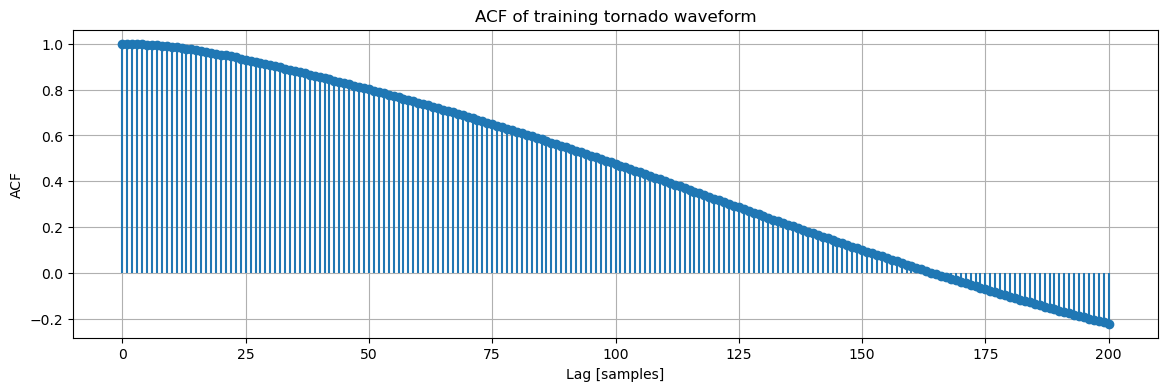

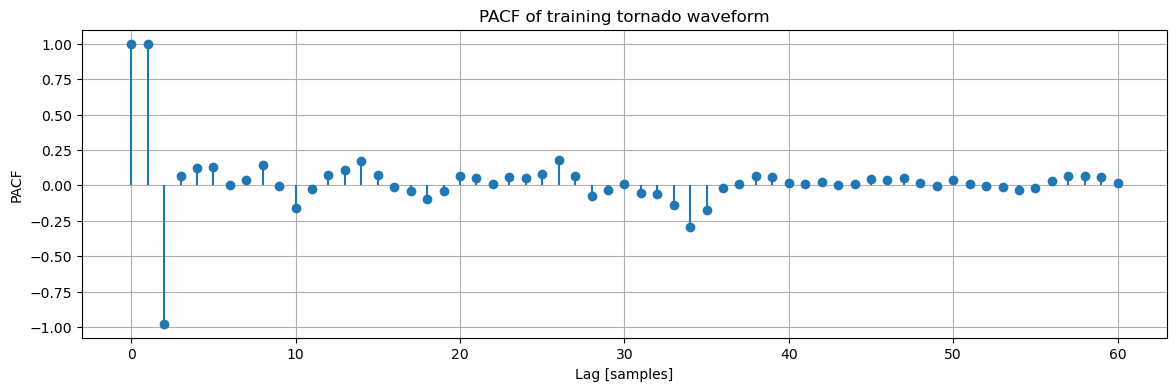

ADF statistic: -27.616671674089712
ADF p-value: 0.0
Selected AR order by BIC: 80


,p,BIC,Training residual std [Pa]
0,2,-1.639253e+06,0.058065
1,4,-1.666783e+06,0.055351
2,6,-1.670300e+06,0.055011
3,8,-1.676854e+06,0.054385
4,10,-1.679939e+06,0.054091


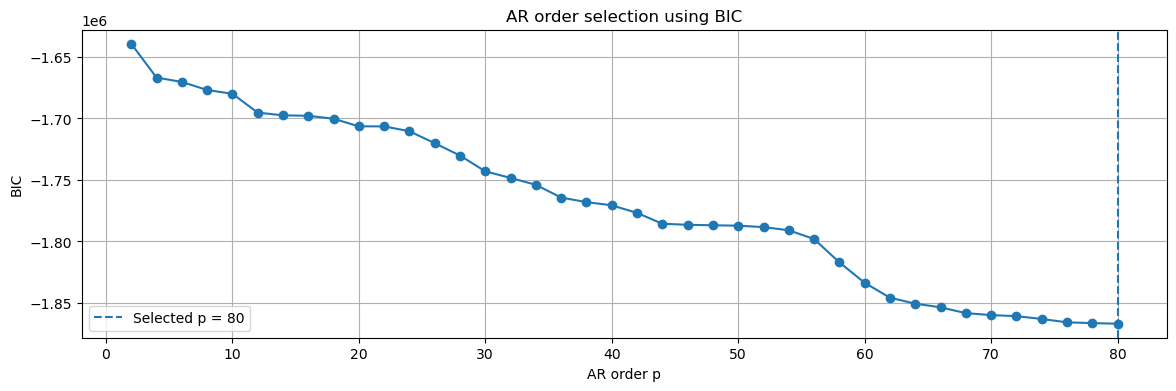

Final AR model
Selected order p: 80
Training residual standard deviation: 0.039009733850158455
Training residual variance: 0.0015217593350601983
AR coefficients:
[-1.28183928e-05  7.58373620e+01 -1.49438098e+02  1.18240129e+02
 -1.06365543e+02  1.49641898e+02 -1.73312162e+02  1.36320645e+02
 -1.05972228e+02  1.70644377e+02 -2.22208595e+02  1.73032547e+02
 -1.41863656e+02  1.62944067e+02 -1.68694473e+02  1.29399824e+02
 -9.57395032e+01  1.59916827e+02 -2.16231665e+02  1.67246645e+02
 -1.39225242e+02  1.71902920e+02 -1.85568393e+02  1.44247026e+02
 -1.11105863e+02  1.49411416e+02 -1.77221802e+02  1.38286612e+02
 -1.11965411e+02  1.18546012e+02 -1.14577017e+02  8.96192187e+01
 -6.67541496e+01  1.57829830e+02 -2.45490053e+02  1.95058186e+02
 -1.70018898e+02  2.10466148e+02 -2.27388747e+02  1.81038968e+02
 -1.39440994e+02  1.95907026e+02 -2.42467047e+02  1.92315128e+02
 -1.57845830e+02  1.59710095e+02 -1.49413479e+02  1.16779569e+02
 -8.29953260e+01  1.12718109e+02 -1.44120308e+02  1.139336

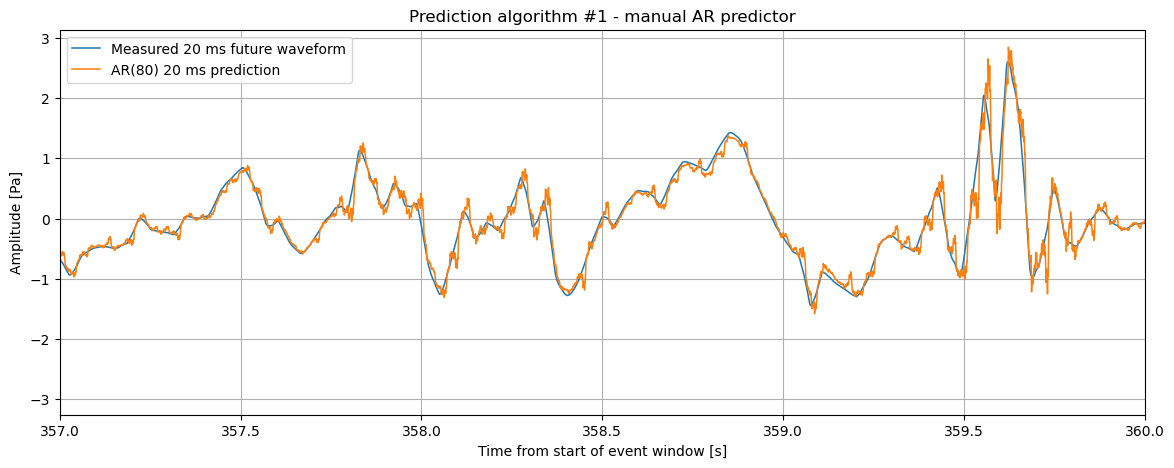

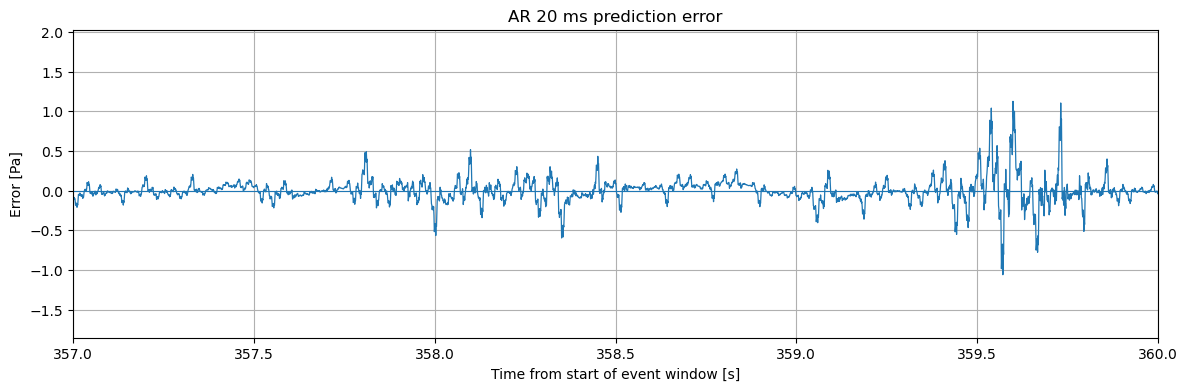

Ljung-Box test on AR training residuals:


,lb_stat,lb_pvalue
10,485988.157236,0.0
20,584053.632686,0.0
40,639624.763124,0.0


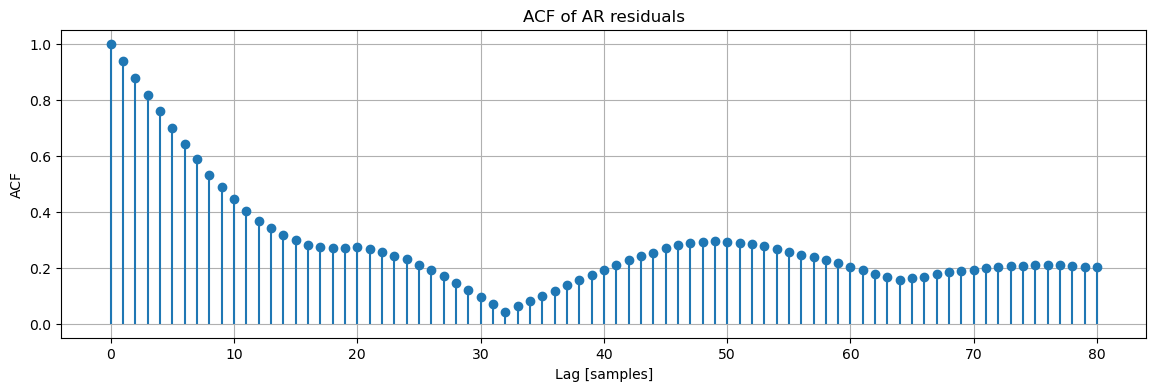

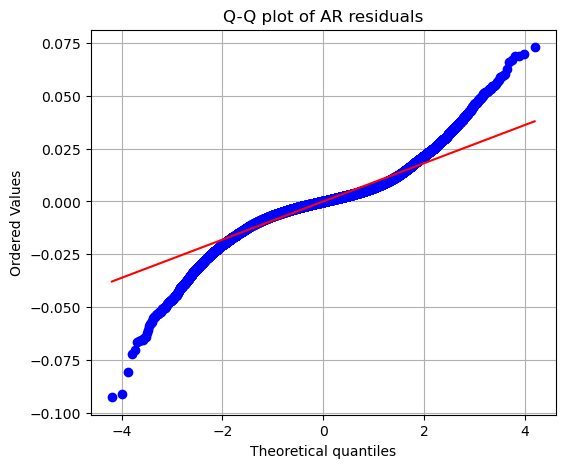

In [16]:
# Analyse the training signal and select the AR model order using BIC.
acf_lags = 200
acf_vals = acf(y_train[:min(len(y_train), 100000)], nlags=acf_lags, fft=True)
pacf_vals = pacf(y_train[:min(len(y_train), 50000)], nlags=60, method='ywm')

plt.figure(figsize=(14,4))
plt.stem(np.arange(len(acf_vals)), acf_vals, basefmt=' ')
plt.title('ACF of training tornado waveform')
plt.xlabel('Lag [samples]')
plt.ylabel('ACF')
plt.show()

plt.figure(figsize=(14,4))
plt.stem(np.arange(len(pacf_vals)), pacf_vals, basefmt=' ')
plt.title('PACF of training tornado waveform')
plt.xlabel('Lag [samples]')
plt.ylabel('PACF')
plt.show()

adf_result = adfuller(y_train[:min(len(y_train), 100000)])
print('ADF statistic:', adf_result[0])
print('ADF p-value:', adf_result[1])

orders = list(range(2, 82, 2))
order_rows = []
models = {}

for p in orders:
    rowsX = []
    target = []
    for n in range(p-1, len(y_train)-horizon_samples):
        rowsX.append([1.0] + [y_train[n-k] for k in range(p)])
        target.append(y_train[n+horizon_samples])
    X = np.array(rowsX)
    target = np.array(target)
    theta = np.linalg.lstsq(X, target, rcond=None)[0]
    residuals = target - X@theta
    sigma2 = np.mean(residuals**2)
    bic_value = len(target)*np.log(sigma2 + 1e-20) + len(theta)*np.log(len(target))
    order_rows.append([p, bic_value, np.std(residuals)])
    models[p] = [theta, residuals]

order_df = pd.DataFrame(order_rows, columns=['p','BIC','Training residual std [Pa]'])
best_p = int(order_df.loc[order_df['BIC'].idxmin(), 'p'])
theta_ar = models[best_p][0]
residuals_ar_train = models[best_p][1]
sigma2_ar = np.mean(residuals_ar_train**2)

print('Selected AR order by BIC:', best_p)
display(order_df.head())

plt.figure(figsize=(14,4))
plt.plot(order_df['p'], order_df['BIC'], marker='o')
plt.axvline(best_p, linestyle='--', label=f'Selected p = {best_p}')
plt.title('AR order selection using BIC')
plt.xlabel('AR order p')
plt.ylabel('BIC')
plt.legend()
plt.show()

print('Final AR model')
print('Selected order p:', best_p)
print('Training residual standard deviation:', np.std(residuals_ar_train))
print('Training residual variance:', sigma2_ar)
print('AR coefficients:')
print(theta_ar)

rowsX = []
target = []
for n in range(best_p-1, len(y_test)-horizon_samples):
    rowsX.append([1.0] + [y_test[n-k] for k in range(best_p)])
    target.append(y_test[n+horizon_samples])
X_test_ar = np.array(rowsX)
ar_actual_test = np.array(target)
ar_pred_test = X_test_ar@theta_ar
ar_time = t_test[(best_p-1+horizon_samples):]

plt.figure(figsize=(14,5))
plt.plot(ar_time, ar_actual_test, label='Measured 20 ms future waveform', linewidth=1.1)
plt.plot(ar_time, ar_pred_test, label=f'AR({best_p}) 20 ms prediction', linewidth=1.1)
plt.title('Prediction algorithm #1 - manual AR predictor')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.xlim(357, 360)
plt.legend()
plt.show()

ar_error = ar_actual_test - ar_pred_test
plt.figure(figsize=(14,4))
plt.plot(ar_time, ar_error, linewidth=0.9)
plt.axhline(0, linewidth=0.8)
plt.title('AR 20 ms prediction error')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Error [Pa]')
plt.xlim(357, 360)
plt.show()

lb_ar = acorr_ljungbox(residuals_ar_train[:min(len(residuals_ar_train), 100000)],
                       lags=[10,20,40], return_df=True)
print('Ljung-Box test on AR training residuals:')
display(lb_ar)

acf_resid_ar = acf(residuals_ar_train[:min(len(residuals_ar_train), 100000)], nlags=80, fft=True)
plt.figure(figsize=(14,4))
plt.stem(np.arange(len(acf_resid_ar)), acf_resid_ar, basefmt=' ')
plt.title('ACF of AR residuals')
plt.xlabel('Lag [samples]')
plt.ylabel('ACF')
plt.show()

plt.figure(figsize=(6,5))
stats.probplot(residuals_ar_train[:min(len(residuals_ar_train), 50000)], dist='norm', plot=plt)
plt.title('Q-Q plot of AR residuals')
plt.show()

## 11.3 Quantitative evaluation (measurement) of the results + rating of the realistically expected performance

### Output 1: ACF, PACF and ADF test

The ACF decreases gradually with increasing lag, indicating that neighbouring samples are strongly correlated. The PACF shows that only the first few lags contribute significantly to the prediction, supporting the use of an autoregressive model.

The ADF test produces a p-value close to zero, indicating that the waveform is sufficiently stationary for AR modelling.

### Output 2: BIC order selection

The BIC curve reaches its minimum at

$$
p=80,
$$

which is selected automatically as the optimum model order. This provides an objective engineering justification for the chosen model complexity.

### Output 3: Prediction and prediction error

The prediction plot shows that the AR model follows the overall behaviour of the measured waveform over the required 20 ms prediction horizon. The prediction error remains centred around zero but increases during rapid waveform changes.

### Output 4: Residual diagnostics

The Ljung-Box test returns very small p-values, indicating that statistically significant autocorrelation remains in the residuals.

The residual ACF also contains several significant peaks rather than resembling white noise, showing that the AR model has not captured all of the predictable structure in the waveform.

The Q-Q plot deviates from the straight reference line, particularly in the tails, indicating that the residuals are not normally distributed.

Overall, the AR predictor provides reasonable short-term prediction performance, but the residual diagnostics indicate that further improvement may still be possible.


## 11.4 Qualitative interpretation of the results

The ACF and PACF confirm that the tornado waveform contains sufficient temporal dependence for autoregressive prediction.

The automatic BIC order selection removes subjectivity from the design process and provides a repeatable method for selecting the model order.

Although the predictor follows the general behaviour of the waveform, the residual diagnostics show that some predictable information remains in the prediction error. The remaining autocorrelation suggests that the transient behaviour of the tornado signal is not completely described by a linear autoregressive model.

The AR predictor therefore provides a suitable baseline prediction algorithm, but a more advanced predictor may produce lower prediction errors for this non-stationary infrasound signal.

# 12. Prediction algorithm #2: Kalman state-space predictor 

## 12.1 Explanation of how it works and evaluation of the code

The Kalman predictor is a recursive state-space prediction method. Unlike the AR predictor, which predicts directly from previous waveform samples, the Kalman predictor represents the signal using internal states.

For this problem, the state vector is

$$
\mathbf{x}[n]
=
\begin{bmatrix}
s[n] \\
\dot{s}[n]
\end{bmatrix},
$$

where $s[n]$ is the signal amplitude and $\dot{s}[n]$ is the local rate of change of the signal.

A constant-velocity model is used:

$$
\mathbf{F}
=
\begin{bmatrix}
1 & \Delta t \\
0 & 1
\end{bmatrix},
\qquad
\mathbf{H}
=
\begin{bmatrix}
1 & 0
\end{bmatrix}.
$$

The prediction step is

$$
\mathbf{x}^{-}[n]
=
\mathbf{F}\mathbf{x}[n-1],
$$

and the measurement update corrects this prediction using the measured waveform value.

The Kalman gain is calculated as

$$
\mathbf{K}[n]
=
\mathbf{P}^{-}[n]\mathbf{H}^{T}
\left(
\mathbf{H}\mathbf{P}^{-}[n]\mathbf{H}^{T}
+
\mathbf{R}
\right)^{-1}.
$$

This gain controls how much the estimate trusts the model prediction compared with the measured waveform.

### Evaluation of the implementation

The code implements the Kalman filter manually using the state transition matrix $\mathbf{F}$, measurement matrix $\mathbf{H}$, process-noise covariance $\mathbf{Q}$, measurement-noise covariance $\mathbf{R}$ and state covariance $\mathbf{P}$.

The measurement-noise covariance $\mathbf{R}$ is estimated from the difference between the raw average waveform and the selected filtered waveform. The process-noise covariance $\mathbf{Q}$ is estimated from the second difference of the waveform, because changes in slope indicate deviation from the constant-velocity model.

The Kalman gain is plotted to show how the model balances measurement correction and prediction.

## 12.2 Motivated design choices

The Kalman predictor was included because it is fundamentally different from the AR predictor. The AR model is a direct time-series regression model, while the Kalman predictor uses a state-space model with uncertainty tracking.

### State choice

The state was chosen as amplitude and slope:

$$
\mathbf{x}[n]
=
\begin{bmatrix}
s[n] \\
\dot{s}[n]
\end{bmatrix}.
$$

This allows the predictor to model both the current waveform value and the local trend of the waveform.

### Prediction horizon

The same prediction horizon of **20 ms** is used so that the Kalman predictor can be compared fairly with the AR predictor.

### Measurement-noise covariance

The measurement-noise covariance $\mathbf{R}$ is estimated from the difference between the raw average waveform and the final filtered waveform. This gives a data-based estimate of the part of the signal removed during preprocessing.

### Process-noise covariance

The process-noise covariance $\mathbf{Q}$ is based on the variance of the second difference of the signal. This is used because the second difference represents changes in slope, which indicate where the constant-velocity model is less accurate.

### Advantages

- Models uncertainty explicitly using $\mathbf{P}$, $\mathbf{Q}$ and $\mathbf{R}$.
- Produces recursive predictions.
- Kalman gain gives an interpretable measure of model-versus-measurement weighting.
- Uses a state-space representation, making it fundamentally different from AR prediction.

### Disadvantages

- A constant-velocity model may be too simple for oscillatory tornado infrasound.
- Performance depends strongly on the choice of $\mathbf{Q}$ and $\mathbf{R}$.
- If the signal changes rapidly, the model may lag behind the waveform.

Measured R from removed noise estimate: 0.3811893856710441
Q matrix:
[[3.29057138e-07 6.58114275e-04]
 [6.58114275e-04 1.31622855e+00]]
R matrix:
[[0.38118939]]
Initial part of Kalman gain:
[[0.00353245 0.        ]
 [0.00352087 0.00172393]
 [0.00351623 0.00688261]
 [0.0035253  0.01546378]
 [0.00355477 0.02745442]]


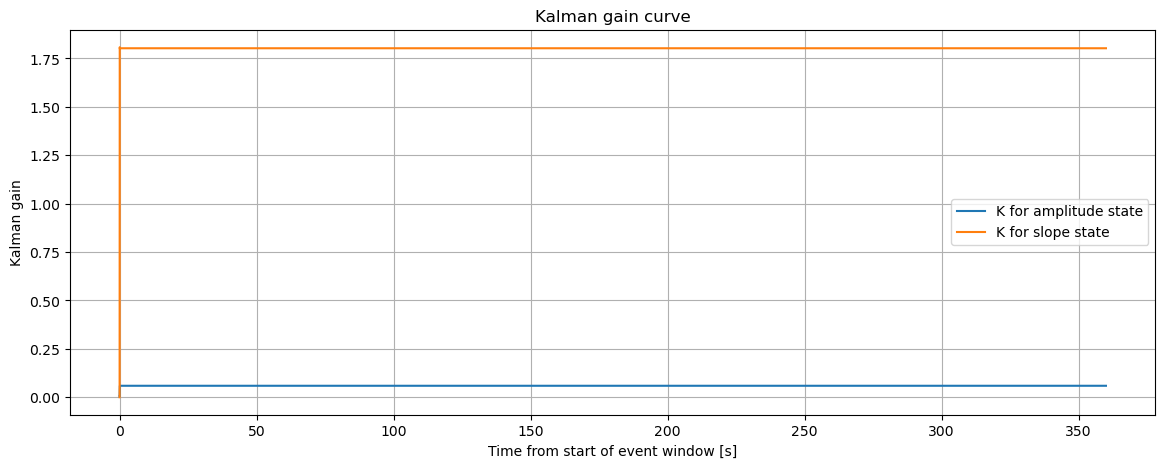

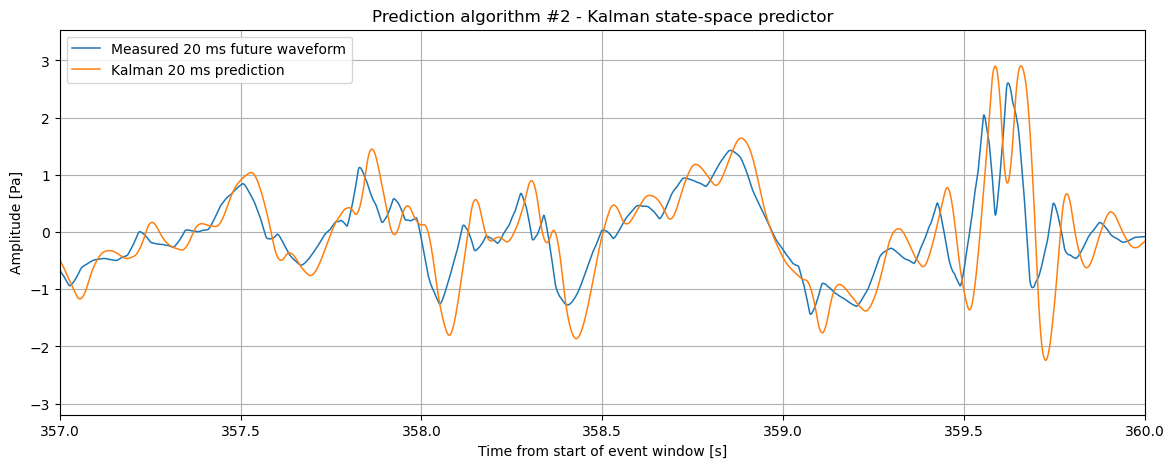

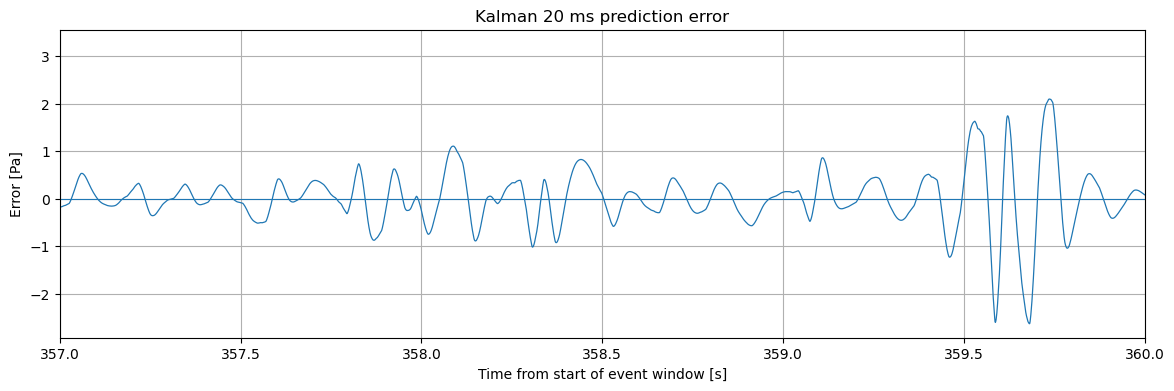

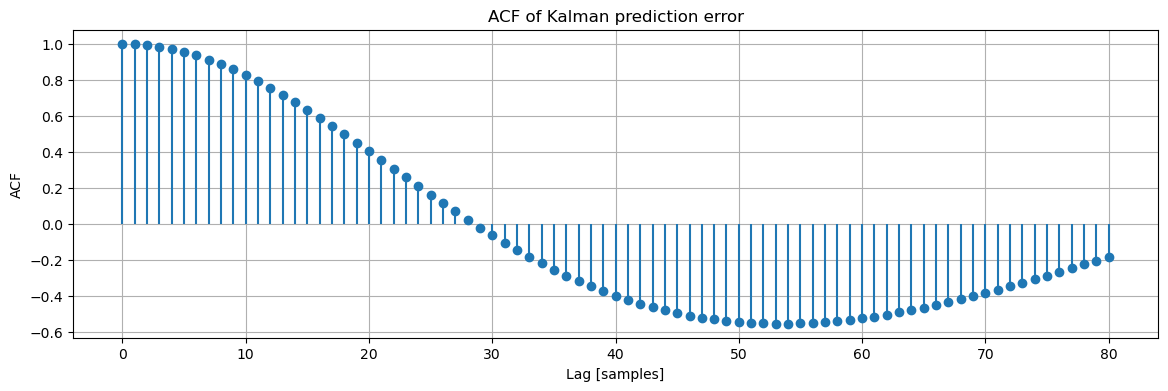

In [17]:
# Run a constant-velocity Kalman predictor for the same 20 ms horizon.
z = y.copy()
dt = 1/fs
N = len(z)
F_kal = np.array([[1.0, dt], [0.0, 1.0]])
H_kal = np.array([[1.0, 0.0]])

noise_estimate = raw_average - tornado_waveform
R_measured = np.var(noise_estimate) # measurement noise covariance
second_diff = np.diff(z, n=2)
accel_var = np.var(second_diff)/(dt**4 + 1e-30)
Q_kal = accel_var*np.array([[dt**4/4, dt**3/2], [dt**3/2, dt**2]])
R_kal = np.array([[R_measured]])

P = np.eye(2)*np.var(z[:min(len(z), int(fs))])
x_state = np.array([z[0], 0.0])
kalman_states = np.zeros((N,2))
K_hist = np.zeros((N,2))
kalman_pred_all = np.full(N, np.nan)
Fh = np.linalg.matrix_power(F_kal, horizon_samples)

for n in range(N):
    if n == 0:
        x_prior = x_state.copy()
        P_prior = P.copy()
    else:
        x_prior = F_kal@x_state
        P_prior = F_kal@P@F_kal.T + Q_kal

    innovation = np.array([[z[n]]]) - H_kal@x_prior.reshape(-1,1)
    S = H_kal@P_prior@H_kal.T + R_kal
    K_gain = P_prior@H_kal.T@np.linalg.inv(S)
    x_state = x_prior + (K_gain@innovation).ravel()
    P = (np.eye(2)-K_gain@H_kal)@P_prior@(np.eye(2)-K_gain@H_kal).T + K_gain@R_kal@K_gain.T

    kalman_states[n, :] = x_state
    K_hist[n, :] = K_gain.ravel()
    kalman_pred_all[n] = (Fh@x_state)[0]

print('Measured R from removed noise estimate:', R_measured)
print('Q matrix:')
print(Q_kal)
print('R matrix:')
print(R_kal)
print('Initial part of Kalman gain:')
print(K_hist[:5])

plt.figure(figsize=(14,5))
plt.plot(t_event, K_hist[:,0], label='K for amplitude state')
plt.plot(t_event, K_hist[:,1], label='K for slope state')
plt.title('Kalman gain curve')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Kalman gain')
plt.legend()
plt.show()

start_n = Ntrain
end_n = len(y) - horizon_samples
kalman_pred_test = kalman_pred_all[start_n:end_n]
kalman_actual_test = y[start_n+horizon_samples:]
kalman_time = t_event[start_n+horizon_samples:end_n+horizon_samples]

plt.figure(figsize=(14,5))
plt.plot(kalman_time, kalman_actual_test, label='Measured 20 ms future waveform', linewidth=1.1)
plt.plot(kalman_time, kalman_pred_test, label='Kalman 20 ms prediction', linewidth=1.1)
plt.title('Prediction algorithm #2 - Kalman state-space predictor')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.xlim(357, 360)
plt.legend()
plt.show()

kalman_error = kalman_actual_test - kalman_pred_test
plt.figure(figsize=(14,4))
plt.plot(kalman_time, kalman_error, linewidth=0.9)
plt.axhline(0, linewidth=0.8)
plt.title('Kalman 20 ms prediction error')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Error [Pa]')
plt.xlim(357, 360)
plt.show()

acf_resid_kalman = acf(kalman_error[:min(len(kalman_error), 100000)], nlags=80, fft=True)
plt.figure(figsize=(14,4))
plt.stem(np.arange(len(acf_resid_kalman)), acf_resid_kalman, basefmt=' ')
plt.title('ACF of Kalman prediction error')
plt.xlabel('Lag [samples]')
plt.ylabel('ACF')
plt.show()

## 12.3 Quantitative evaluation of the results and rating of the realistically expected performance

### Output 1: Kalman gain curve

The Kalman gain curve shows how strongly the state estimate is corrected by the measurement.

The amplitude-state Kalman gain remains small, meaning the amplitude estimate is corrected only moderately by each new measurement. The slope-state gain is larger, indicating that the model makes stronger corrections to the local trend of the waveform.

This behaviour is controlled by the state covariance $\mathbf{P}$, process-noise covariance $\mathbf{Q}$ and measurement-noise covariance $\mathbf{R}$. The gain is therefore not determined by $\mathbf{Q}/\mathbf{R}$ alone.

### Output 2: Kalman 20 ms prediction

The Kalman prediction follows the broad waveform behaviour, but it does not track the rapid transient changes as closely as the AR predictor.

This is expected because the constant-velocity state model is relatively simple and cannot fully represent the oscillatory structure of the tornado waveform.

### Output 3: Kalman prediction error

The prediction-error plot shows that the Kalman error increases during periods of rapid waveform variation. This indicates that the model struggles when the signal changes faster than the constant-velocity assumption can represent.

### Output 4: ACF of Kalman prediction error

The ACF of the Kalman prediction error shows strong remaining autocorrelation. This means that the prediction error still contains structured information rather than behaving like white noise.

This suggests that the constant-velocity Kalman model under-models the waveform dynamics.

### Rating of realistically expected performance

The Kalman predictor is useful because it provides a clear state-space interpretation and explicitly models uncertainty. However, the simple constant-velocity model is not complex enough to capture the rapidly changing tornado waveform.

**Performance rating: Moderate**

The Kalman predictor is valuable for comparison, but it is not expected to outperform the AR predictor for this dataset.

## 12.4 Qualitative interpretation of the results

Qualitatively, the Kalman predictor provides a smoother and more model-based forecast than the AR predictor. It is useful because it gives an interpretable state-space representation of the waveform and shows how the prediction is updated through the Kalman gain.

However, the prediction plot and error plot show that the constant-velocity model cannot follow rapid oscillations and transients very accurately. The tornado waveform changes too quickly for a simple amplitude-and-slope state model to capture all of its behaviour.

The prediction-error ACF confirms this limitation. Since the error remains strongly autocorrelated, the Kalman predictor leaves structured information unmodelled.

Overall, the Kalman method is a valid and fundamentally different prediction technique, but its simple state-space model is less suitable than the AR model for this specific 20 ms waveform prediction task.

# 13. Prediction comparison

## 13.1 Comparison method

The AR and Kalman predictors are compared using the same test section of the selected tornado waveform. Both models predict the waveform 20 ms into the future.

The comparison uses four error measures:

$$
e[n] = y_{\text{actual}}[n] - y_{\text{predicted}}[n]
$$

$$
MAE = \frac{1}{N}\sum_{n=1}^{N}|e[n]|
$$

$$
RMSE = \sqrt{\frac{1}{N}\sum_{n=1}^{N}e[n]^2}
$$

$$
Bias = \frac{1}{N}\sum_{n=1}^{N}e[n]
$$

MAE and RMSE measure the prediction error. Bias shows whether the model over-predicts or under-predicts on average. The correlation coefficient shows how well the predicted waveform follows the measured waveform shape.

,MAE [Pa],RMSE [Pa],Bias [Pa],Correlation
Prediction algorithm,,,,
Manual AR(80),0.060648,0.104887,-0.000042,0.976273
Kalman constant-velocity,0.254365,0.388415,0.000018,0.764854


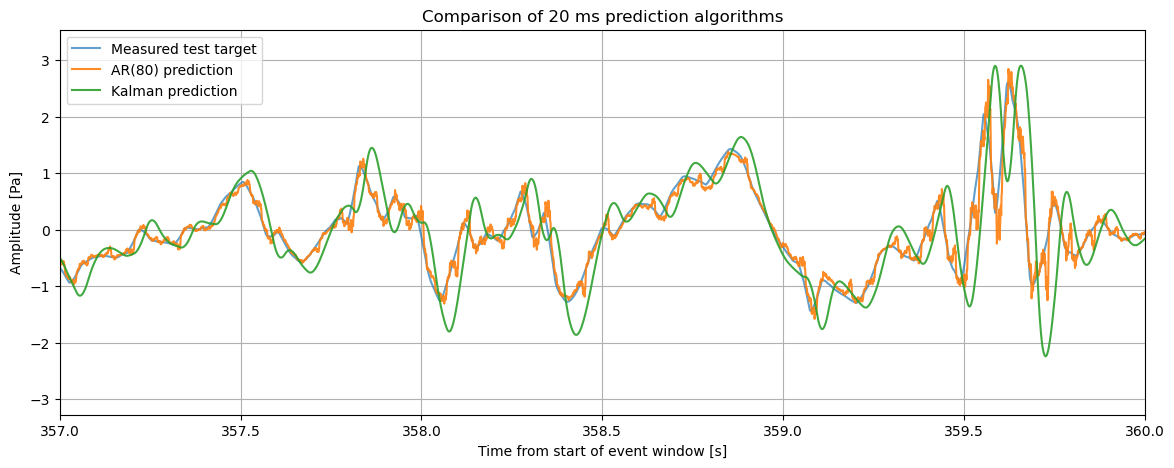

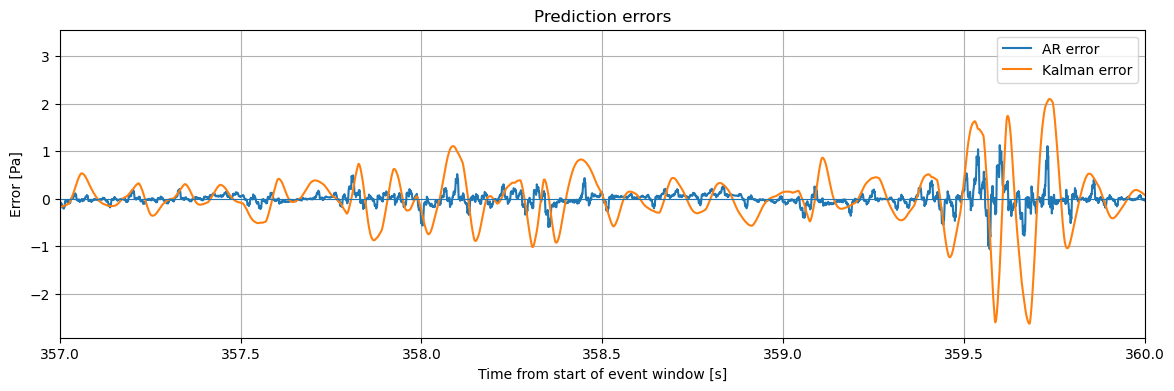

In [18]:
# Compare both prediction algorithms using the same error measures.

ar_mae = np.mean(np.abs(ar_actual_test - ar_pred_test))
ar_rmse = np.sqrt(np.mean((ar_actual_test - ar_pred_test)**2))
ar_bias = np.mean(ar_actual_test - ar_pred_test)
ar_corr = np.corrcoef(ar_actual_test, ar_pred_test)[0,1]

kal_mae = np.mean(np.abs(kalman_actual_test - kalman_pred_test))
kal_rmse = np.sqrt(np.mean((kalman_actual_test - kalman_pred_test)**2))
kal_bias = np.mean(kalman_actual_test - kalman_pred_test)
kal_corr = np.corrcoef(kalman_actual_test, kalman_pred_test)[0,1]

prediction_results = pd.DataFrame([
    [f'Manual AR({best_p})', ar_mae, ar_rmse, ar_bias, ar_corr],
    ['Kalman constant-velocity', kal_mae, kal_rmse, kal_bias, kal_corr]
], columns=['Prediction algorithm','MAE [Pa]','RMSE [Pa]','Bias [Pa]','Correlation']).set_index('Prediction algorithm')

display(prediction_results)

plt.figure(figsize=(14,5))
plt.plot(ar_time, ar_actual_test, label='Measured test target', alpha=0.7)
plt.plot(ar_time, ar_pred_test, label=f'AR({best_p}) prediction', alpha=0.9)
plt.plot(kalman_time, kalman_pred_test, label='Kalman prediction', alpha=0.9)
plt.title('Comparison of 20 ms prediction algorithms')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Amplitude [Pa]')
plt.xlim(357, 360)
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(ar_time, ar_error, label='AR error')
plt.plot(kalman_time, kalman_error, label='Kalman error')
plt.axhline(0, linewidth=0.8)
plt.title('Prediction errors')
plt.xlabel('Time from start of event window [s]')
plt.ylabel('Error [Pa]')
plt.xlim(357, 360)
plt.legend()
plt.show()

## 13.2 Quantitative comparison of prediction results

The manual AR predictor gives the best numerical prediction performance.

The AR predictor achieves:

- MAE = 0.060648 Pa
- RMSE = 0.104887 Pa
- Bias = -0.000042 Pa
- Correlation = 0.976273

The Kalman constant-velocity predictor achieves:

- MAE = 0.254365 Pa
- RMSE = 0.388415 Pa
- Bias = 0.000018 Pa
- Correlation = 0.764854

The AR predictor has the lower MAE and RMSE, and the higher correlation coefficient. This means that it follows the measured waveform more closely over the 20 ms prediction horizon.

## 13.3 Qualitative interpretation of prediction results

The AR predictor performs better because the tornado waveform has strong short-term autocorrelation. This means that nearby samples contain useful information for predicting the waveform 20 ms ahead.

The Kalman predictor is smoother, but the constant-velocity model is too simple for the rapidly changing waveform. This causes larger errors during transient parts of the signal.

Overall, the manual AR predictor is selected as the better prediction method for the 20 ms prediction task.

# 14. Final TDOA-ready output

The final output of this notebook is the selected filtered three-channel microphone signal. This signal is not used to calculate the final tornado bearing in this notebook. Instead, it is prepared for a later TDOA localisation algorithm.

The selected preprocessing method is the DWT filter because it gives the highest average cross-correlation peak-to-median ratio while still improving the spectral concentration in the expected tornado band.

As a final verification step, the cross-correlations between the microphone pairs are calculated once more. The delays must remain inside the physically possible range:

$$
|\tau| \leq \frac{62}{343} \approx 0.181~\text{s}.
$$

The filtered east, north and west microphone signals are then saved to a CSV file for later TDOA localisation.

,Signal,Pair,Delay [samples],Delay [ms],Correlation peak,Peak-to-median ratio
0,Final DWT,east-north,-181,-181.0,-0.024926,3.864013
1,Final DWT,east-west,-28,-28.0,0.024217,2.239193
2,Final DWT,north-west,181,181.0,-0.057692,3.213819


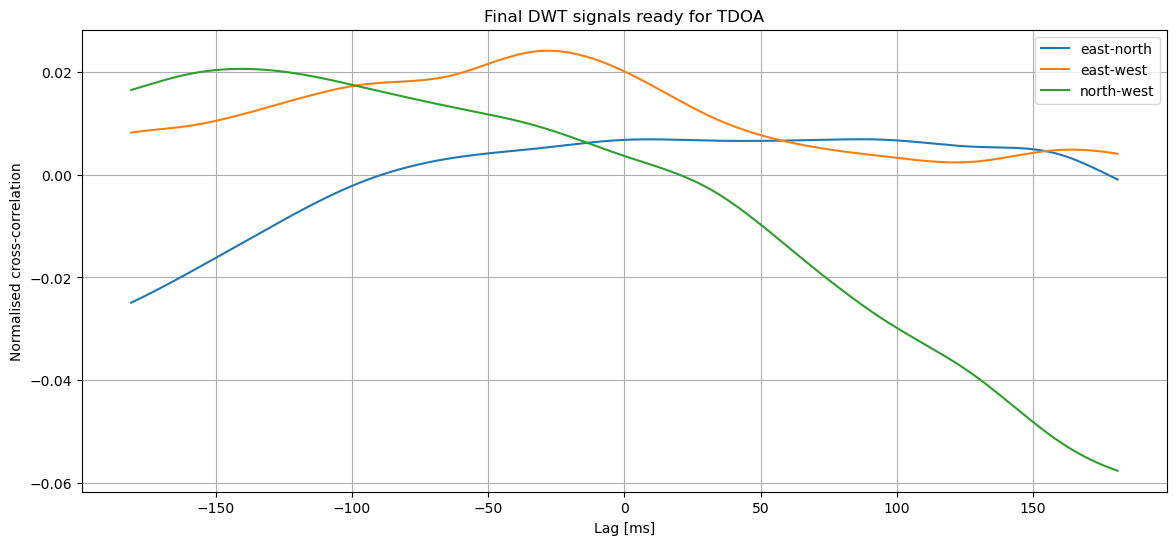

Saved: Tornado_TDOA_ready_filtered_signals.csv


In [19]:
# Verify the final filtered signals and save them for later TDOA localisation.

rows = []
final_corr = {}

for ch1, ch2 in pairs:
    x = final_filtered[ch1].to_numpy(dtype=float)
    y = final_filtered[ch2].to_numpy(dtype=float)

    x = (x - np.mean(x))/(np.std(x)+1e-12)
    y = (y - np.mean(y))/(np.std(y)+1e-12)

    r = np.zeros(len(lags))

    for i, lag in enumerate(lags):
        if lag < 0:
            r[i] = np.sum(x[-lag:]*y[:len(y)+lag])
        elif lag > 0:
            r[i] = np.sum(x[:-lag]*y[lag:])
        else:
            r[i] = np.sum(x*y)

    r = r/len(x)
    final_corr[(ch1,ch2)] = r

    loc = np.argmax(np.abs(r))

    rows.append([f'Final {final_filter_name}',
                 f'{ch1}-{ch2}',
                 lags[loc],
                 1000*lags[loc]/fs,
                 r[loc],
                 abs(r[loc])/(np.median(np.abs(r))+1e-12)])

final_tdoa = pd.DataFrame(rows, columns=raw_tdoa.columns)
display(final_tdoa)

plt.figure(figsize=(14,6))
for ch1, ch2 in pairs:
    plt.plot(1000*lags/fs, final_corr[(ch1,ch2)], label=f'{ch1}-{ch2}')

plt.title(f'Final {final_filter_name} signals ready for TDOA')
plt.xlabel('Lag [ms]')
plt.ylabel('Normalised cross-correlation')
plt.legend()
plt.show()

final_output = pd.DataFrame({
    'time_s_event': t_event,
    'east_filtered': final_filtered['east'].to_numpy(dtype=float),
    'north_filtered': final_filtered['north'].to_numpy(dtype=float),
    'west_filtered': final_filtered['west'].to_numpy(dtype=float)
})

final_output.to_csv('Tornado_TDOA_ready_filtered_signals.csv', index=False)
print('Saved: Tornado_TDOA_ready_filtered_signals.csv')

## 14.1 Interpretation of the final output

The final TDOA table shows that the selected filtered signals still produce physically possible delays. The cross-correlation peak-to-median ratios are higher than the raw signal values, which means that the selected preprocessing method improves the clarity of the TDOA peaks.

The final CSV file is the practical output of the preprocessing stage. It contains the filtered east, north and west microphone signals, which can be used by a later TDOA localisation algorithm.

# 15. Final conclusion

This notebook investigated the preprocessing and short-term prediction of tornado infrasound recordings using techniques covered in EERI 414.

The signals were analysed in both the time and frequency domains before four fundamentally different preprocessing methods were implemented and compared:

1. Butterworth IIR filtering,
2. windowed Fourier-series FIR filtering,
3. principal component analysis,
4. discrete wavelet transform filtering.

Each filtering method was evaluated using the same quantitative performance measures, including band preservation, out-of-band suppression and TDOA cross-correlation quality. This allowed the final preprocessing method to be selected objectively rather than by visual inspection alone.

The DWT filter provided the best overall balance between preserving transient waveform features and improving cross-correlation quality. It was therefore selected as the final preprocessing method and the filtered microphone signals were exported for later TDOA localisation.

Two prediction algorithms were then implemented for the required 20 ms prediction task:

1. a manually derived autoregressive predictor,
2. a Kalman state-space predictor.

Both predictors were evaluated using identical test data and common error metrics. The manual AR predictor achieved lower MAE and RMSE together with higher waveform correlation than the Kalman predictor, making it the preferred prediction algorithm for this dataset.

Overall, the notebook demonstrates the complete processing chain from raw tornado recordings to TDOA-ready signals and short-term waveform prediction using techniques developed during the course.

## Limitation

The objective of this notebook was preprocessing and prediction rather than localisation. Determining the tornado arrival direction would require the known microphone geometry together with the measured TDOA values produced during preprocessing.

### Design justification and output interpretation: final saved output

The saved CSV is the practical output of the preprocessing task. It contains the filtered east, north and west microphone signals. A later TDOA algorithm can use these three channels to estimate the tornado direction.
